# Notebook 05 — XGBoost & LightGBM · Three Quantile Models + Optuna Tuning

**Objective:** Train and compare **LightGBM** and **XGBoost** for the Egypt used-car pricing problem.  
Both frameworks are trained with **three independent quantile models** (lower q=0.10, median q=0.50, upper q=0.90) to produce negotiation price ranges.

## Notebook Structure
1. **Imports & config**
2. **Load & sanity-check data** (same processed dataset as notebook 04)
3. **Preprocessing** — feature typing (cat / numeric), missing-value handling, LightGBM `category` dtype, XGBoost label encoding
4. **Five split strategies A–E** (identical to the linear models baseline notebook 04)
5. **Optuna hyperparameter tuning** — median model search, params reused for lower/upper
6. **Train three quantile models per framework × all splits**
7. **Point-estimate evaluation** — full table + best-split summary (mirrors notebook 04 style)
8. **Best-split plots** — Top-2 by R², Top-2 by MAE+MAPE (one 2×2 grid per framework)
9. **Quantile / CI evaluation** — coverage, width, monotonicity, band plots
10. **Segmented evaluation** — per-brand, per-price-tier
11. **5-fold CV** on median model (official GP defense metric)
12. **Optuna convergence & param importance**
13. **SHAP analysis** — global bar, beeswarm, dependence, waterfall
14. **Residual analysis**
15. **LightGBM vs XGBoost verdict** — radar chart + target check table
16. **Export artifacts** — model files, label encoders, metadata.json, quantile_registry.json


## 1) Imports & Configuration

In [15]:
import sys, warnings, json, datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sklearn.model_selection import (
    train_test_split, KFold, GroupShuffleSplit,
)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

import lightgbm as lgb
import xgboost as xgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import shap
import joblib

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-dark')

In [16]:
# ── Locate ml-service root ────────────────────────────────────────────────────
def find_ml_root(start=None):
    start = (start or Path.cwd()).resolve()
    for c in (start, *start.parents):
        if (c / 'app' / 'core' / 'config.py').exists():
            return c
    raise FileNotFoundError('Cannot find ml-service root')

ML_ROOT = find_ml_root()
if str(ML_ROOT) not in sys.path:
    sys.path.insert(0, str(ML_ROOT))

from app.core.config import settings

In [17]:
# ── Reproducibility 
RANDOM_STATE = 42
TEST_SIZE    = 0.20    

# ── Targets to benchmark (train on raw EGP and/or log-price) 
# Each entry will run independently and produce its own results table in the baseline the loged values was better.
TARGETS_TO_BENCH = ['price_egp', 'price_egp_log']

# ── Quantile alphas 
QUANTILES = {'lower': 0.05, 'median': 0.50, 'upper': 0.95}

# ── Optuna  50-100 recommended 
N_TRIALS = 100
EARLY_STOPPING_ROUNDS = 50
N_ESTIMATORS_MAX      = 2000

# ── Export 
MODEL_VERSION = 'v1.0.0'
OUT_DIR  = ML_ROOT / 'models' / 'pickles'
PLOT_DIR = ML_ROOT / 'models' / 'plots_05_xgboost_lgbm_quantile'
OUT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

print('Artifact dir:', OUT_DIR)
print('Plot dir:    ', PLOT_DIR)

Artifact dir: /home/mo-seif/Documents/GP/ml-service/models/pickles
Plot dir:     /home/mo-seif/Documents/GP/ml-service/models/plots_05_xgboost_lgbm_quantile


## 2) Load Data

In [18]:
df_raw = settings.load_data('processed').copy()

print('Raw dataset shape:', df_raw.shape)
display(df_raw.head(3))

Raw dataset shape: (20214, 18)


,make,model,year,car_age,transmission,fuel,mileage_km,mileage_per_year,location,engine_cc,horsepower,body_type,drivetrain,seating_capacity,brand_origin,car_segment,price_egp,price_egp_log
0,BYD,F3,2024,2,Manual,petrol,"4,410.000","2,205.000",Giza,1500,109,Sedan,FWD,5,chinese,family,630000,13.353
1,BYD,F3,2025,1,Manual,petrol,"33,033.000","33,033.000",Nasr City,1500,109,Sedan,FWD,5,chinese,family,610000,13.321
2,Subaru,Impreza,2009,17,Manual,petrol,"98,000.000","5,764.706",Maadi,1498,107,Sedan,AWD,5,japanese,family,410000,12.924


## 2.1) Quick Sanity Checks

In [19]:
info = pd.DataFrame({
    'dtype'  : df_raw.dtypes,
    'nulls'  : df_raw.isnull().sum(),
    'nunique': df_raw.nunique(),
})
display(info)

,dtype,nulls,nunique
make,str,0,73
model,str,0,523
year,int64,0,52
car_age,int64,0,52
transmission,str,0,4
fuel,str,0,5
mileage_km,float64,0,1321
mileage_per_year,float64,0,3859
location,str,0,17
engine_cc,int64,0,32


price_egp stats:


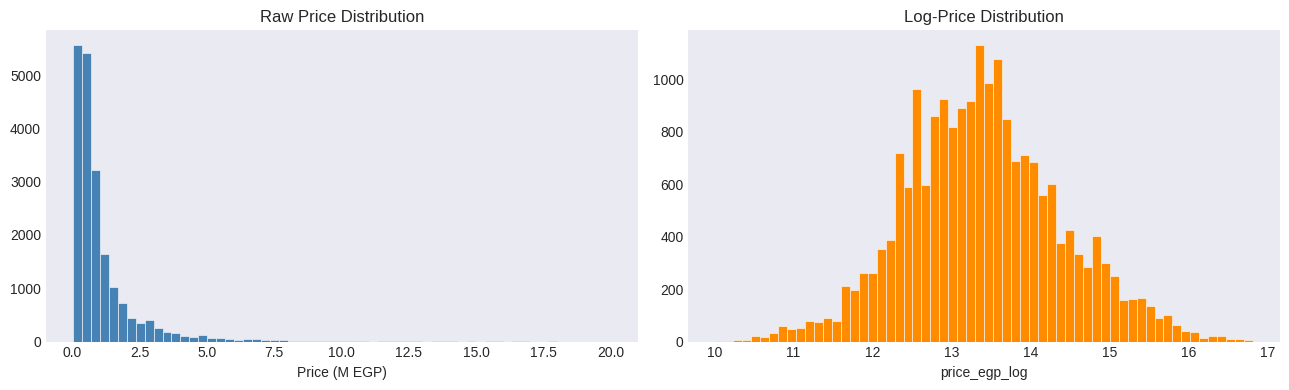

In [20]:
print('price_egp stats:')
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df_raw['price_egp'] / 1e6, bins=60, color='steelblue', edgecolor='white', lw=0.4)
axes[0].set_xlabel('Price (M EGP)'); axes[0].set_title('Raw Price Distribution')
axes[1].hist(df_raw['price_egp_log'], bins=60, color='darkorange', edgecolor='white', lw=0.4)
axes[1].set_xlabel('price_egp_log'); axes[1].set_title('Log-Price Distribution')
plt.tight_layout(); plt.show()

## 3) Preprocessing

### Strategy
| Aspect | LightGBM | XGBoost |
|--------|----------|---------|
| Categorical encoding | **Native** — cast to pandas `category` dtype | **Label-encoded** as integers (`enable_categorical=True`) |
| Missing values | Built-in NaN handling | Built-in NaN handling (with `enable_categorical`) |
| Numeric features | Unchanged (LightGBM handles natively) | Unchanged |
| Rare categories (< 10 rows) | Grouped into `OTHER_{make}` | Same grouping applied before encoding |

All preprocessing is **fit on training data only** — no leakage into test/val sets.

In [21]:
DROP_COLS  = {'price_egp', 'price_egp_log', 'car_age'}

CAT_COLS = ['make', 'model', 'transmission', 'fuel', 'location',
            'body_type', 'drivetrain', 'brand_origin', 'car_segment']

NUM_COLS = [c for c in df_raw.columns if c not in DROP_COLS and c not in CAT_COLS]

FEATURE_COLS = NUM_COLS + CAT_COLS

print(f'Numeric features  ({len(NUM_COLS)}) : {NUM_COLS}')
print(f'Categorical feat. ({len(CAT_COLS)}) : {CAT_COLS}')
print(f'Total features    : {len(FEATURE_COLS)}')

Numeric features  (6) : ['year', 'mileage_km', 'mileage_per_year', 'engine_cc', 'horsepower', 'seating_capacity']
Categorical feat. (9) : ['make', 'model', 'transmission', 'fuel', 'location', 'body_type', 'drivetrain', 'brand_origin', 'car_segment']
Total features    : 15


In [22]:
# ── Rare-category grouping (fitted once on full df, same logic applied per split) ─
# For make+model combos with < 10 rows we collapse model into 'OTHER_{make}'.
# This is a GLOBAL reference table — actual application is inside split helpers.
MIN_ROWS_PER_MODEL = 5
_model_counts = df_raw.groupby(['make', 'model']).size().reset_index(name='n')
_rare_models   = _model_counts.loc[_model_counts['n'] < MIN_ROWS_PER_MODEL]
RARE_MODEL_SET = set(zip(_rare_models['make'], _rare_models['model']))

print(f'Total (make, model) combos  : {len(_model_counts)}')
print(f'Rare combos (< {MIN_ROWS_PER_MODEL} rows)  : {len(RARE_MODEL_SET)}')

def apply_rare_grouping(df: pd.DataFrame) -> pd.DataFrame:
    """Replace rare (make, model) models with OTHER_{make} — no leakage since
    RARE_MODEL_SET is computed on the full dataset (or training partition)."""
    df = df.copy()
    if 'model' in df.columns and 'make' in df.columns:
        mask = [( m, mo) in RARE_MODEL_SET
                for m, mo in zip(df['make'], df['model'])]
        df.loc[mask, 'model'] = df.loc[mask, 'make'].apply(lambda x: f'OTHER_{x}')
    return df

df_raw = apply_rare_grouping(df_raw)
print('Applied rare-model grouping to full dataset.')

Total (make, model) combos  : 537
Rare combos (< 5 rows)  : 22
Applied rare-model grouping to full dataset.


In [23]:
# ── LightGBM feature matrix: cast categorical cols to 'category' dtype ────────
def make_lgbm_frame(df: pd.DataFrame) -> pd.DataFrame:
    """Return feature matrix formatted for LightGBM (category dtype)."""
    X = df[FEATURE_COLS].copy()
    for c in CAT_COLS:
        X[c] = X[c].astype('category')
    return X

# ── XGBoost: label-encode categoricals as integers ────────────────────────────
# We fit LabelEncoders on the FULL dataset here so unseen values in any test
# split map to a known integer.  This is standard practice for XGBoost.
label_encoders: dict[str, LabelEncoder] = {}
df_xgb_encoded = df_raw[FEATURE_COLS].copy()

for c in CAT_COLS:
    le = LabelEncoder()
    df_xgb_encoded[c] = le.fit_transform(
        df_xgb_encoded[c].fillna('__MISSING__').astype(str)
    )
    label_encoders[c] = le

print('LightGBM dtypes after category cast:')
display(make_lgbm_frame(df_raw)[CAT_COLS].dtypes.rename('dtype').to_frame())

print('\nXGBoost dtypes after label encoding:')
display(df_xgb_encoded[CAT_COLS].dtypes.rename('dtype').to_frame())

LightGBM dtypes after category cast:


,dtype
make,category
model,category
transmission,category
fuel,category
location,category
body_type,category
drivetrain,category
brand_origin,category
car_segment,category



XGBoost dtypes after label encoding:


,dtype
make,int64
model,int64
transmission,int64
fuel,int64
location,int64
body_type,int64
drivetrain,int64
brand_origin,int64
car_segment,int64


In [24]:
# ── Verify: no remaining nulls in either matrix ───────────────────────────────
X_lgbm_all = make_lgbm_frame(df_raw)
X_xgb_all  = df_xgb_encoded.copy()

assert X_lgbm_all.isnull().sum().sum() == 0, 'LightGBM features have nulls!'
assert X_xgb_all.isnull().sum().sum()  == 0, 'XGBoost features have nulls!'

print('✓ No missing values in either feature matrix.')
print('Shapes — LightGBM:', X_lgbm_all.shape, '  XGBoost:', X_xgb_all.shape)

✓ No missing values in either feature matrix.
Shapes — LightGBM: (20214, 15)   XGBoost: (20214, 15)


## 4) Split Strategies (A – E)
**Same five splits as baseline notebook 04** for fair apples-to-apples comparison.

In [25]:
rng = np.random.default_rng(RANDOM_STATE)

# ── Helper: robust stratification bins ───────────────────────────────────────
def _build_price_bins(price: pd.Series, desired_bins: int = 10) -> pd.Series:
    s = pd.to_numeric(price, errors='coerce').fillna(price.median())
    for q in [desired_bins, 8, 6, 5, 4, 3]:
        try:
            b = pd.qcut(s, q=q, duplicates='drop')
        except Exception:
            continue
        codes = b.cat.codes.astype(int)
        rare  = codes.value_counts()[codes.value_counts() < 2].index
        codes = codes.where(~codes.isin(rare), -1)
        if codes.value_counts().min() >= 2:
            return codes
    return pd.Series(np.zeros(len(s), dtype=int), index=price.index)

# ── A) Pure random ────────────────────────────────────────────────────────────
idx_all = df_raw.index.to_numpy()
tr_A, te_A = train_test_split(idx_all, test_size=TEST_SIZE, random_state=RANDOM_STATE)

# ── B) 80/20 within each (make, model) ───────────────────────────────────────
def split_within_make_model(df_full):
    train_idx, test_idx = [], []
    for (_, _), gdf in df_full.groupby(['make', 'model'], sort=False):
        n = len(gdf)
        if n < 5:
            train_idx.extend(gdf.index.tolist()); continue
        n_test = max(1, min(int(np.floor(TEST_SIZE * n)), n - 1))
        chosen = set(rng.choice(gdf.index.to_numpy(), size=n_test, replace=False).tolist())
        test_idx.extend(list(chosen))
        train_idx.extend([i for i in gdf.index.tolist() if i not in chosen])
    assert set(train_idx).isdisjoint(set(test_idx))
    return np.array(train_idx), np.array(test_idx)

tr_B, te_B = split_within_make_model(df_raw)

# ── C) Split by make only (hardest) ──────────────────────────────────────────
splitter = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
tr_C_i, te_C_i = next(splitter.split(df_raw, groups=df_raw['make']))
tr_C, te_C = df_raw.index[tr_C_i].to_numpy(), df_raw.index[te_C_i].to_numpy()

# ── D) Stratified by make ─────────────────────────────────────────────────────
make_counts = df_raw['make'].value_counts()
strat_make  = df_raw['make'].where(df_raw['make'].map(make_counts) >= 2, 'RARE_MAKE')
tr_D, te_D  = train_test_split(idx_all, test_size=TEST_SIZE, random_state=RANDOM_STATE,
                                stratify=strat_make)

# ── E) Stratified by price bins ───────────────────────────────────────────────
strat_price = _build_price_bins(df_raw['price_egp'])
tr_E, te_E  = train_test_split(idx_all, test_size=TEST_SIZE, random_state=RANDOM_STATE,
                                stratify=strat_price)

# ── Registry ──────────────────────────────────────────────────────────────────
split_indices: dict[str, tuple] = {
    'A_random_rows'               : (tr_A, te_A),
    'B_within_make_model_rows'    : (tr_B, te_B),
    'C_split_by_make_only'        : (tr_C, te_C),
    'D_stratified_by_make'        : (tr_D, te_D),
    'E_stratified_by_price_range' : (tr_E, te_E),
}

for name, (tr, te) in split_indices.items():
    print(f'{name:<35}  train: {len(tr):,}   test: {len(te):,}')

A_random_rows                        train: 16,171   test: 4,043
B_within_make_model_rows             train: 16,367   test: 3,847
C_split_by_make_only                 train: 16,237   test: 3,977
D_stratified_by_make                 train: 16,171   test: 4,043
E_stratified_by_price_range          train: 16,171   test: 4,043


## 5) Metric Helpers

In [26]:
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
np.set_printoptions(suppress=True)


def compute_metrics_egp(y_true: np.ndarray, y_pred: np.ndarray,
                         is_log: bool = False) -> dict:
    """Regression metrics — always returned in EGP space."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    if is_log:
        # detect log10 vs ln by median scale
        med = float(np.median(y_true))
        if med < 10:           # log10: values ~5-7 → exp10
            y_true = np.power(10, y_true)
            y_pred = np.power(10, y_pred)
        else:                  # ln: values ~12-16 → exp
            y_true = np.exp(y_true)
            y_pred = np.exp(y_pred)

    mae     = float(mean_absolute_error(y_true, y_pred))
    rmse    = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    r2      = float(r2_score(y_true, y_pred))
    eps     = 1e-9
    denom   = np.maximum(np.abs(y_true), eps)
    mape    = float(np.mean(np.abs((y_true - y_pred) / denom)) * 100)
    w10     = float(np.mean(np.abs((y_true - y_pred) / denom) <= 0.10) * 100)
    w15     = float(np.mean(np.abs((y_true - y_pred) / denom) <= 0.15) * 100)

    return dict(MAE=mae, RMSE=rmse, R2=r2, MAPE_pct=mape,
                Within_10pct=w10, Within_15pct=w15,
                # store raw arrays for plots
                _y_true_egp=y_true, _y_pred_egp=y_pred)


def compute_ci_metrics(y_true, y_lo, y_med, y_hi) -> dict:
    """Quantile-interval quality checks (doc §03 — Confidence Intervals)."""
    y_true = np.asarray(y_true, dtype=float)
    y_lo   = np.clip(np.asarray(y_lo,  dtype=float), 0, None)   # no negative prices
    y_med  = np.asarray(y_med, dtype=float)
    y_hi   = np.asarray(y_hi,  dtype=float)

    # enforce monotonicity post-hoc
    y_lo  = np.minimum(y_lo,  y_med)
    y_hi  = np.maximum(y_hi,  y_med)

    coverage  = float(np.mean((y_true >= y_lo) & (y_true <= y_hi)) * 100)
    mono_viol = int(np.sum((y_lo > y_med) | (y_med > y_hi)))
    eps       = 1e-9
    rel_width = (y_hi - y_lo) / np.maximum(np.abs(y_med), eps)
    mean_w    = float(np.mean(rel_width) * 100)
    n_neg     = int(np.sum(y_lo < 0))

    return dict(Coverage_pct=coverage, Mono_violations=mono_viol,
                Mean_width_pct=mean_w, N_neg_lower=n_neg)


print('Metric helpers ready.')

Metric helpers ready.


## 6) Optuna Tuning

Tune on the **median model (q=0.50)** using split **D** (stratified by make — recommended production split).
Best params are then reused for the lower and upper models.

In [27]:
TUNE_SPLIT = 'E_stratified_by_price_range'
tr_tune, te_tune = split_indices[TUNE_SPLIT]

# ── Internal validation (10% of training) for early stopping during tuning ────
rng_tune = np.random.default_rng(RANDOM_STATE)
val_n    = max(1, int(len(tr_tune) * 0.10))
val_tune = rng_tune.choice(tr_tune, size=val_n, replace=False)
tr_tune_ = np.array([i for i in tr_tune if i not in set(val_tune.tolist())])

print(f'Tuning split : {TUNE_SPLIT}')
print(f'  train      : {len(tr_tune_):,}   inner-val : {len(val_tune):,}   test : {len(te_tune):,}')

Tuning split : E_stratified_by_price_range
  train      : 14,554   inner-val : 1,617   test : 4,043


In [28]:
# ──────────────────────────────────────────────────────────────────────────────
#  6.1  LightGBM Optuna Study
# ──────────────────────────────────────────────────────────────────────────────
X_tr_lgbm_tune = X_lgbm_all.loc[tr_tune_]
y_tr_lgbm_tune = df_raw.loc[tr_tune_, 'price_egp_log']
X_vl_lgbm_tune = X_lgbm_all.loc[val_tune]
y_vl_lgbm_tune = df_raw.loc[val_tune, 'price_egp_log']

dt_lgbm = lgb.Dataset(X_tr_lgbm_tune, label=y_tr_lgbm_tune,
                       categorical_feature=CAT_COLS, free_raw_data=False)
dv_lgbm = lgb.Dataset(X_vl_lgbm_tune, label=y_vl_lgbm_tune,
                       categorical_feature=CAT_COLS, free_raw_data=False,
                       reference=dt_lgbm)

def lgbm_objective(trial):
    params = {
        'objective'        : 'quantile',
        'alpha'            : 0.5,
        'metric'           : 'quantile',
        'verbosity'        : -1,
        'n_jobs'           : -1,
        'seed'             : RANDOM_STATE,
        'subsample_freq'   : 1,
        'learning_rate'    : trial.suggest_float('learning_rate',    0.01,  0.30, log=True),
        'num_leaves'       : trial.suggest_int(  'num_leaves',       15,    127),
        'max_depth'        : trial.suggest_int(  'max_depth',        3,     12),
        'min_child_samples': trial.suggest_int(  'min_child_samples',10,    100),
        'subsample'        : trial.suggest_float('subsample',        0.5,   1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5,   1.0),
        'reg_alpha'        : trial.suggest_float('reg_alpha',        1e-8,  10.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda',       1e-8,  10.0, log=True),
        'min_split_gain'   : trial.suggest_float('min_split_gain',   0.0,   1.0),
    }
    model = lgb.train(
        params, dt_lgbm, num_boost_round=N_ESTIMATORS_MAX, valid_sets=[dv_lgbm],
        callbacks=[lgb.early_stopping(EARLY_STOPPING_ROUNDS, verbose=False),
                   lgb.log_evaluation(-1)],
    )
    preds = model.predict(X_vl_lgbm_tune)
    resid = y_vl_lgbm_tune.to_numpy() - preds
    return float(np.mean(np.where(resid >= 0, 0.5 * resid, -0.5 * resid)))   # pinball

print(f'Running {N_TRIALS} Optuna trials for LightGBM ...')
lgbm_study = optuna.create_study(direction='minimize',
                                  sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
lgbm_study.optimize(lgbm_objective, n_trials=N_TRIALS, show_progress_bar=True)

LGBM_BEST = lgbm_study.best_params
print('\nBest LightGBM params:')
for k, v in LGBM_BEST.items(): print(f'  {k}: {v}')
print(f'  Best pinball loss: {lgbm_study.best_value:.4f}')

Running 100 Optuna trials for LightGBM ...


  0%|          | 0/100 [00:00<?, ?it/s]

[LightGBM] [Fatal] Reducing `min_data_in_leaf` with `feature_pre_filter=true` may cause unexpected behaviour for features that were pre-filtered by the larger `min_data_in_leaf`.
You need to set `feature_pre_filter=false` to dynamically change the `min_data_in_leaf`.
[LightGBM] [Fatal] Reducing `min_data_in_leaf` with `feature_pre_filter=true` may cause unexpected behaviour for features that were pre-filtered by the larger `min_data_in_leaf`.
You need to set `feature_pre_filter=false` to dynamically change the `min_data_in_leaf`.
[LightGBM] [Fatal] Reducing `min_data_in_leaf` with `feature_pre_filter=true` may cause unexpected behaviour for features that were pre-filtered by the larger `min_data_in_leaf`.
You need to set `feature_pre_filter=false` to dynamically change the `min_data_in_leaf`.
[LightGBM] [Fatal] Reducing `min_data_in_leaf` with `feature_pre_filter=true` may cause unexpected behaviour for features that were pre-filtered by the larger `min_data_in_leaf`.
You need to set `


Best LightGBM params:
  learning_rate: 0.027681271280960946
  num_leaves: 62
  max_depth: 10
  min_child_samples: 12
  subsample: 0.715216053848345
  colsample_bytree: 0.5431488908733526
  reg_alpha: 0.49247701388255255
  reg_lambda: 1.7238989341211074e-05
  min_split_gain: 0.02774152144413644
  Best pinball loss: 0.0630


In [30]:
# ──────────────────────────────────────────────────────────────────────────────
#  6.2  XGBoost Optuna Study
# ──────────────────────────────────────────────────────────────────────────────
X_tr_xgb_tune = X_xgb_all.loc[tr_tune_]
y_tr_xgb_tune = df_raw.loc[tr_tune_, 'price_egp_log']
X_vl_xgb_tune = X_xgb_all.loc[val_tune]
y_vl_xgb_tune = df_raw.loc[val_tune, 'price_egp_log']

dm_tr_xgb = xgb.DMatrix(X_tr_xgb_tune, label=y_tr_xgb_tune, enable_categorical=True)
dm_vl_xgb = xgb.DMatrix(X_vl_xgb_tune, label=y_vl_xgb_tune, enable_categorical=True)

def xgb_objective(trial):
    params = {
        'objective'       : 'reg:quantileerror',
        'quantile_alpha'  : 0.5,
        'eval_metric'     : 'quantile',
        'tree_method'     : 'hist',
        'device'          : 'cpu',
        'seed'            : RANDOM_STATE,
        'nthread'         : -1,
        'verbosity'       : 0,
        'learning_rate'   : trial.suggest_float('learning_rate',   0.01, 0.30, log=True),
        'max_depth'       : trial.suggest_int(  'max_depth',       3,    12),
        'min_child_weight': trial.suggest_int(  'min_child_weight',1,    50),
        'subsample'       : trial.suggest_float('subsample',       0.5,  1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree',0.5,  1.0),
        'reg_alpha'       : trial.suggest_float('reg_alpha',       1e-8, 10.0, log=True),
        'reg_lambda'      : trial.suggest_float('reg_lambda',      1e-8, 10.0, log=True),
        'gamma'           : trial.suggest_float('gamma',           0.0,  5.0),
        'max_bin'         : trial.suggest_categorical('max_bin',   [128, 256, 512]),
    }
    model = xgb.train(
        params, dm_tr_xgb, num_boost_round=N_ESTIMATORS_MAX,
        evals=[(dm_vl_xgb, 'val')],
        early_stopping_rounds=EARLY_STOPPING_ROUNDS,
        verbose_eval=False,
    )
    preds = model.predict(dm_vl_xgb)
    resid = y_vl_xgb_tune.to_numpy() - preds
    return float(np.mean(np.where(resid >= 0, 0.5 * resid, -0.5 * resid)))

print(f'Running {N_TRIALS} Optuna trials for XGBoost ...')
xgb_study = optuna.create_study(direction='minimize',
                                 sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
xgb_study.optimize(xgb_objective, n_trials=N_TRIALS, show_progress_bar=True)

XGB_BEST = xgb_study.best_params
print('\nBest XGBoost params:')
for k, v in XGB_BEST.items(): print(f'  {k}: {v}')
print(f'  Best pinball loss: {xgb_study.best_value:.4f}')

Running 100 Optuna trials for XGBoost ...


  0%|          | 0/100 [00:00<?, ?it/s]


Best XGBoost params:
  learning_rate: 0.015490483286740053
  max_depth: 11
  min_child_weight: 4
  subsample: 0.6622077411666858
  colsample_bytree: 0.8536659127023519
  reg_alpha: 0.085522303812033
  reg_lambda: 1.3969605300880791e-07
  gamma: 0.447036756545783
  max_bin: 512
  Best pinball loss: 0.0627


## 7) Train Three Quantile Models × All Splits

In [31]:
# ── Training helpers ──────────────────────────────────────────────────────────
QUANTILES = {'lower': 0.05, 'median': 0.50, 'upper': 0.95}


def _inner_val_split(tr_idx: np.ndarray):
    """Carve 10% of training indices for early stopping."""
    rng_l   = np.random.default_rng(RANDOM_STATE)
    val_n   = max(1, int(len(tr_idx) * 0.10))
    val_idx = rng_l.choice(tr_idx, size=val_n, replace=False)
    tr_idx_ = np.array([i for i in tr_idx if i not in set(val_idx.tolist())])
    return tr_idx_, val_idx


def train_lgbm_trio(tr_idx: np.ndarray, target_col: str) -> dict:
    """Train lower/median/upper LightGBM models for a given split & target."""
    t_idx, v_idx = _inner_val_split(tr_idx)
    is_log = (target_col == 'price_egp_log')

    X_t = X_lgbm_all.loc[t_idx];  y_t = df_raw.loc[t_idx, target_col]
    X_v = X_lgbm_all.loc[v_idx];  y_v = df_raw.loc[v_idx, target_col]

    models = {}
    for q_name, alpha in QUANTILES.items():
        params = {
            **LGBM_BEST,
            'objective': 'quantile', 'alpha': alpha,
            'metric': 'quantile', 'verbosity': -1,
            'n_jobs': -1, 'seed': RANDOM_STATE, 'subsample_freq': 1,
        }
        dt = lgb.Dataset(X_t, label=y_t, categorical_feature=CAT_COLS, free_raw_data=False)
        dv = lgb.Dataset(X_v, label=y_v, categorical_feature=CAT_COLS, free_raw_data=False,
                         reference=dt)
        m  = lgb.train(params, dt, num_boost_round=N_ESTIMATORS_MAX,
                        valid_sets=[dv],
                        callbacks=[lgb.early_stopping(EARLY_STOPPING_ROUNDS, verbose=False),
                                   lgb.log_evaluation(-1)])
        models[q_name] = m
    return models


def train_xgb_trio(tr_idx: np.ndarray, target_col: str) -> dict:
    """Train lower/median/upper XGBoost models for a given split & target."""
    t_idx, v_idx = _inner_val_split(tr_idx)

    X_t = X_xgb_all.loc[t_idx];  y_t = df_raw.loc[t_idx, target_col]
    X_v = X_xgb_all.loc[v_idx];  y_v = df_raw.loc[v_idx, target_col]

    dm_t = xgb.DMatrix(X_t, label=y_t, enable_categorical=True)
    dm_v = xgb.DMatrix(X_v, label=y_v, enable_categorical=True)

    models = {}
    for q_name, alpha in QUANTILES.items():
        params = {
            **XGB_BEST,
            'objective': 'reg:quantileerror', 'quantile_alpha': alpha,
            'eval_metric': 'quantile', 'tree_method': 'hist',
            'device': 'cpu', 'seed': RANDOM_STATE,
            'nthread': -1, 'verbosity': 0,
        }
        m = xgb.train(params, dm_t, num_boost_round=N_ESTIMATORS_MAX,
                       evals=[(dm_v, 'val')],
                       early_stopping_rounds=EARLY_STOPPING_ROUNDS,
                       verbose_eval=False)
        models[q_name] = m
    return models


print('Training helpers ready.')

Training helpers ready.


In [32]:
# ── Train all frameworks × splits × targets ───────────────────────────────────
# lgbm_store[target][split] = {'lower': model, 'median': model, 'upper': model}
lgbm_store: dict[str, dict] = {t: {} for t in TARGETS_TO_BENCH}
xgb_store:  dict[str, dict] = {t: {} for t in TARGETS_TO_BENCH}

for target in TARGETS_TO_BENCH:
    is_log = (target == 'price_egp_log')
    print(f'\n=== Target: {target} ===')
    for split_name, (tr_idx, te_idx) in split_indices.items():
        print(f'  [{split_name}]')
        lgbm_store[target][split_name] = train_lgbm_trio(tr_idx, target)
        xgb_store[target][split_name]  = train_xgb_trio(tr_idx, target)

print('\n✓ All models trained.')


=== Target: price_egp ===
  [A_random_rows]


  [B_within_make_model_rows]
  [C_split_by_make_only]
  [D_stratified_by_make]
  [E_stratified_by_price_range]

=== Target: price_egp_log ===
  [A_random_rows]
  [B_within_make_model_rows]
  [C_split_by_make_only]
  [D_stratified_by_make]
  [E_stratified_by_price_range]

✓ All models trained.


## 8) Point-Estimate Evaluation — All Splits & Targets

Metrics evaluated in **EGP space** for both raw and log-price targets (same convention as notebook 04).

In [33]:
# ── Collect results ───────────────────────────────────────────────────────────
# results_by_target[target] = DataFrame with columns:
#   framework, split, MAE, RMSE, MAPE_pct, R2, Within_10pct, Within_15pct
# pred_store[target][split][framework] = {'y_true_egp', 'y_pred_egp'}

results_by_target: dict[str, pd.DataFrame] = {}
pred_store:        dict[str, dict]          = {}

for target in TARGETS_TO_BENCH:
    is_log = (target == 'price_egp_log')
    rows   = []
    pred_store[target] = {}

    for split_name, (tr_idx, te_idx) in split_indices.items():
        y_te_raw = df_raw.loc[te_idx, target].to_numpy()
        y_te_egp = df_raw.loc[te_idx, 'price_egp'].to_numpy()

        pred_store[target][split_name] = {}

        for fw, store in [('LightGBM', lgbm_store), ('XGBoost', xgb_store)]:
            med_model = store[target][split_name]['median']

            if fw == 'LightGBM':
                y_pred_raw = med_model.predict(X_lgbm_all.loc[te_idx])
            else:
                dm = xgb.DMatrix(X_xgb_all.loc[te_idx], enable_categorical=True)
                y_pred_raw = med_model.predict(dm)

            m = compute_metrics_egp(y_te_raw, y_pred_raw, is_log=is_log)

            # store raw egp arrays for plotting
            pred_store[target][split_name][fw] = {
                'y_true_egp': m.pop('_y_true_egp'),
                'y_pred_egp': m.pop('_y_pred_egp'),
            }

            rows.append(dict(train_target=target, framework=fw, split=split_name,
                             eval_space='EGP', **m))

    df_res = pd.DataFrame(rows)
    results_by_target[target] = df_res

print('Evaluation complete.')

Evaluation complete.


In [34]:
# ── Combined table: all targets, all splits, all frameworks ───────────────────
results_all = pd.concat(list(results_by_target.values()), ignore_index=True)

col_order = ['train_target', 'eval_space', 'framework', 'split',
             'MAE', 'RMSE', 'MAPE_pct', 'R2']
results_all = results_all[[c for c in col_order if c in results_all.columns]]
results_all = results_all.sort_values(['train_target', 'framework', 'MAPE_pct']).reset_index(drop=True)

fmt = results_all.copy()
for c in ['MAE', 'RMSE']:
    fmt[c] = fmt[c].apply(lambda v: f'{float(v):,.0f}')
for c in ['MAPE_pct', 'R2']:
    fmt[c] = fmt[c].apply(lambda v: f'{float(v):.3f}')

display(fmt)

,train_target,eval_space,framework,split,MAE,RMSE,MAPE_pct,R2
0,price_egp,EGP,LightGBM,A_random_rows,"139,828","462,505",13.584,0.907
1,price_egp,EGP,LightGBM,E_stratified_by_price_range,"147,359","492,288",13.617,0.879
2,price_egp,EGP,LightGBM,D_stratified_by_make,"149,373","515,113",14.227,0.879
3,price_egp,EGP,LightGBM,B_within_make_model_rows,"152,749","582,831",15.327,0.850
4,price_egp,EGP,LightGBM,C_split_by_make_only,"918,832","1,514,509",38.997,0.415
5,price_egp,EGP,XGBoost,A_random_rows,"134,638","420,509",13.273,0.923
6,price_egp,EGP,XGBoost,E_stratified_by_price_range,"138,277","463,948",13.534,0.893
7,price_egp,EGP,XGBoost,D_stratified_by_make,"141,489","483,530",13.946,0.894
8,price_egp,EGP,XGBoost,B_within_make_model_rows,"143,636","542,404",14.941,0.870
9,price_egp,EGP,XGBoost,C_split_by_make_only,"796,546","1,421,904",34.236,0.484


In [35]:
# ── Best configuration per (target, framework) — ranked by MAE+MAPE ───────────
# Mirrors notebook 04's "best model" summary cell
best_rows = []
for target, df_res in results_by_target.items():
    for fw, sub in df_res.groupby('framework'):
        sub = sub.copy()
        sub['_rank_mae']   = sub['MAE'].rank(method='dense', ascending=True)
        sub['_rank_mape']  = sub['MAPE_pct'].rank(method='dense', ascending=True)
        sub['_score']      = 2.0 * sub['_rank_mae'] + 1.0 * sub['_rank_mape']
        best = sub.sort_values(['_score', 'MAE', 'MAPE_pct'], ascending=[True, True, True]).iloc[0]
        best_rows.append(dict(
            train_target = target,
            eval_space   = 'EGP',
            framework    = fw,
            best_split   = best['split'],
            test_MAE     = best['MAE'],
            test_RMSE    = best['RMSE'],
            test_MAPE_pct= best['MAPE_pct'],
            test_R2      = best['R2'],
            Within_15pct = best['Within_15pct'],
        ))

best_df = pd.DataFrame(best_rows).sort_values(['train_target', 'test_MAPE_pct']).reset_index(drop=True)
print('\n=== Best configuration per (target, framework) [ranked by MAE+MAPE] ===')
display(best_df)


=== Best configuration per (target, framework) [ranked by MAE+MAPE] ===


,train_target,eval_space,framework,best_split,test_MAE,test_RMSE,test_MAPE_pct,test_R2,Within_15pct
0,price_egp,EGP,XGBoost,A_random_rows,"134,637.595","420,509.143",13.273,0.923,73.856
1,price_egp,EGP,LightGBM,A_random_rows,"139,828.477","462,504.681",13.584,0.907,74.450
2,price_egp_log,EGP,LightGBM,A_random_rows,"136,347.651","452,769.362",12.881,0.911,75.563
3,price_egp_log,EGP,XGBoost,A_random_rows,"137,495.509","442,252.603",12.912,0.915,74.351


In [36]:
# ── Per-framework: best split across all splits ───────────────────────────────
for target in TARGETS_TO_BENCH:
    df_res = results_by_target[target]
    for fw in ['LightGBM', 'XGBoost']:
        sub = df_res[df_res['framework'] == fw].copy()
        sub = sub[['split', 'MAE', 'RMSE', 'R2', 'MAPE_pct']].sort_values('MAPE_pct')
        print(f'\n=== {fw} results | target = {target} ===')
        display(sub.reset_index(drop=True))


=== LightGBM results | target = price_egp ===


,split,MAE,RMSE,R2,MAPE_pct
0,A_random_rows,"139,828.477","462,504.681",0.907,13.584
1,E_stratified_by_price_range,"147,359.366","492,287.951",0.879,13.617
2,D_stratified_by_make,"149,372.715","515,112.745",0.879,14.227
3,B_within_make_model_rows,"152,749.087","582,831.265",0.850,15.327
4,C_split_by_make_only,"918,832.312","1,514,508.794",0.415,38.997



=== XGBoost results | target = price_egp ===


,split,MAE,RMSE,R2,MAPE_pct
0,A_random_rows,"134,637.595","420,509.143",0.923,13.273
1,E_stratified_by_price_range,"138,277.465","463,948.495",0.893,13.534
2,D_stratified_by_make,"141,488.967","483,529.785",0.894,13.946
3,B_within_make_model_rows,"143,635.937","542,403.604",0.870,14.941
4,C_split_by_make_only,"796,546.425","1,421,904.243",0.484,34.236



=== LightGBM results | target = price_egp_log ===


,split,MAE,RMSE,R2,MAPE_pct
0,A_random_rows,"136,347.651","452,769.362",0.911,12.881
1,E_stratified_by_price_range,"146,194.696","499,512.573",0.875,13.105
2,D_stratified_by_make,"145,725.813","517,254.804",0.878,13.398
3,B_within_make_model_rows,"147,365.627","575,662.427",0.854,14.426
4,C_split_by_make_only,"948,804.459","1,593,350.681",0.352,37.597



=== XGBoost results | target = price_egp_log ===


,split,MAE,RMSE,R2,MAPE_pct
0,A_random_rows,"137,495.509","442,252.603",0.915,12.912
1,E_stratified_by_price_range,"143,124.841","485,220.837",0.882,13.204
2,D_stratified_by_make,"139,806.170","480,410.186",0.895,13.344
3,B_within_make_model_rows,"143,774.567","552,960.164",0.865,14.528
4,C_split_by_make_only,"844,316.113","1,477,421.906",0.443,34.172


## 8.1) Best-Split Plots (mirrors notebook 04 style)

For **each framework** we automatically select:
- **Top 2 by R²** (highest)
- **Top 2 by MAE+MAPE** (lowest combined rank)

And draw the 2×2 Predicted vs Actual grid.


=== LightGBM | target = price_egp ===
Top 2 by R²:


,split,MAE,MAPE_pct,R2,Within_15pct
0,A_random_rows,"139,828.477",13.584,0.907,74.450
1,D_stratified_by_make,"149,372.715",14.227,0.879,75.068


Top 2 by lowest MAE+MAPE:


,split,MAE,MAPE_pct,R2,Within_15pct
0,A_random_rows,"139,828.477",13.584,0.907,74.450
1,E_stratified_by_price_range,"147,359.366",13.617,0.879,74.153


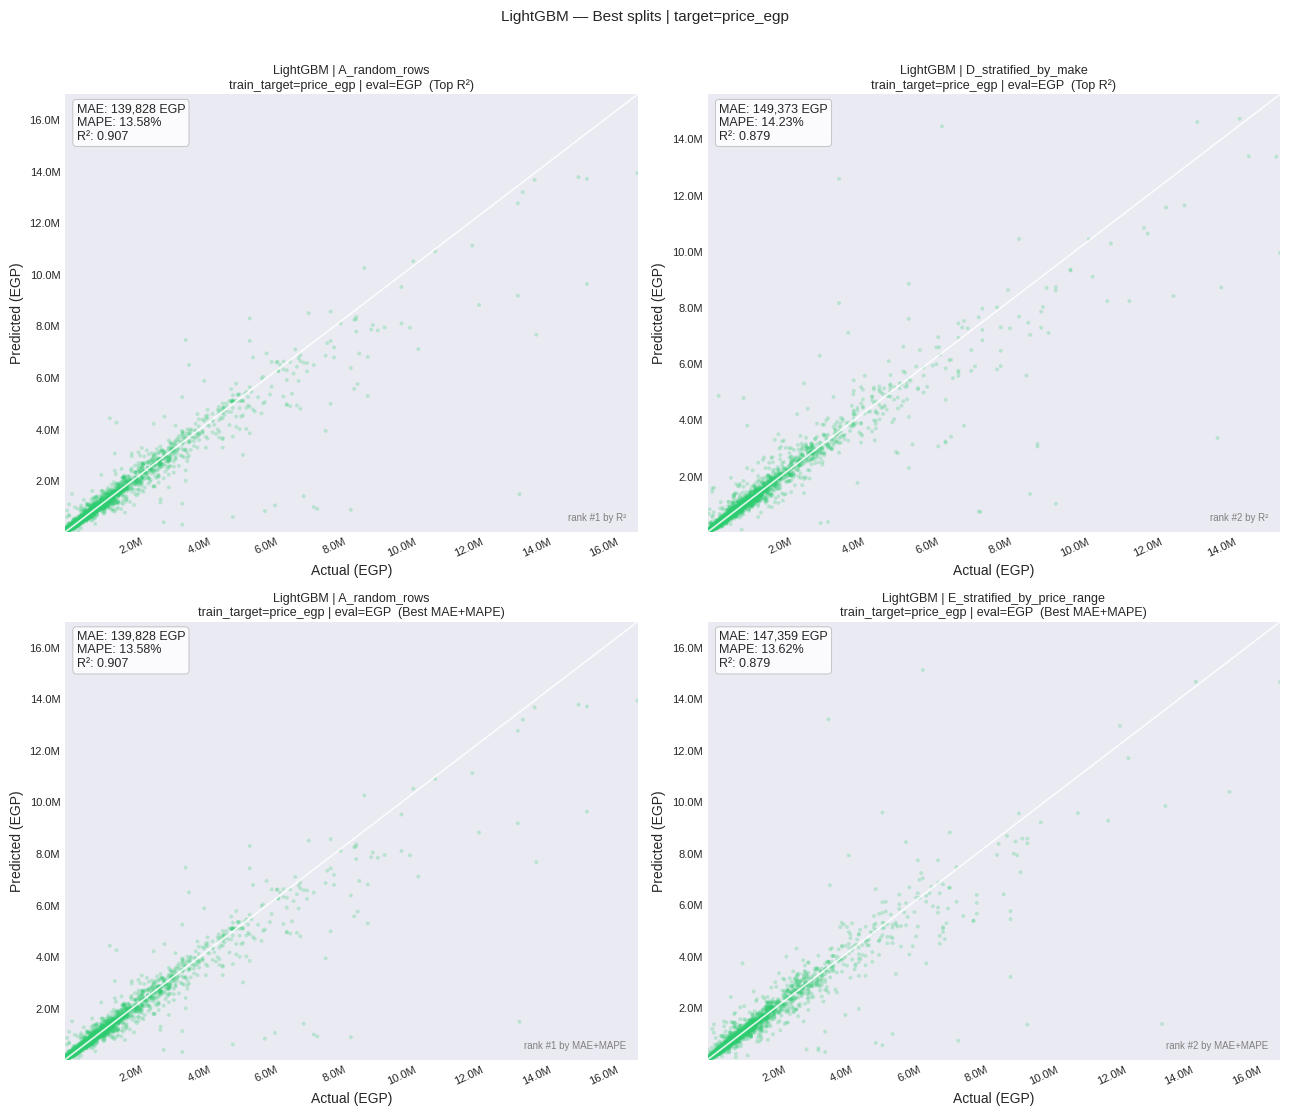


=== XGBoost | target = price_egp ===
Top 2 by R²:


,split,MAE,MAPE_pct,R2,Within_15pct
0,A_random_rows,"134,637.595",13.273,0.923,73.856
1,D_stratified_by_make,"141,488.967",13.946,0.894,75.439


Top 2 by lowest MAE+MAPE:


,split,MAE,MAPE_pct,R2,Within_15pct
0,A_random_rows,"134,637.595",13.273,0.923,73.856
1,E_stratified_by_price_range,"138,277.465",13.534,0.893,74.499


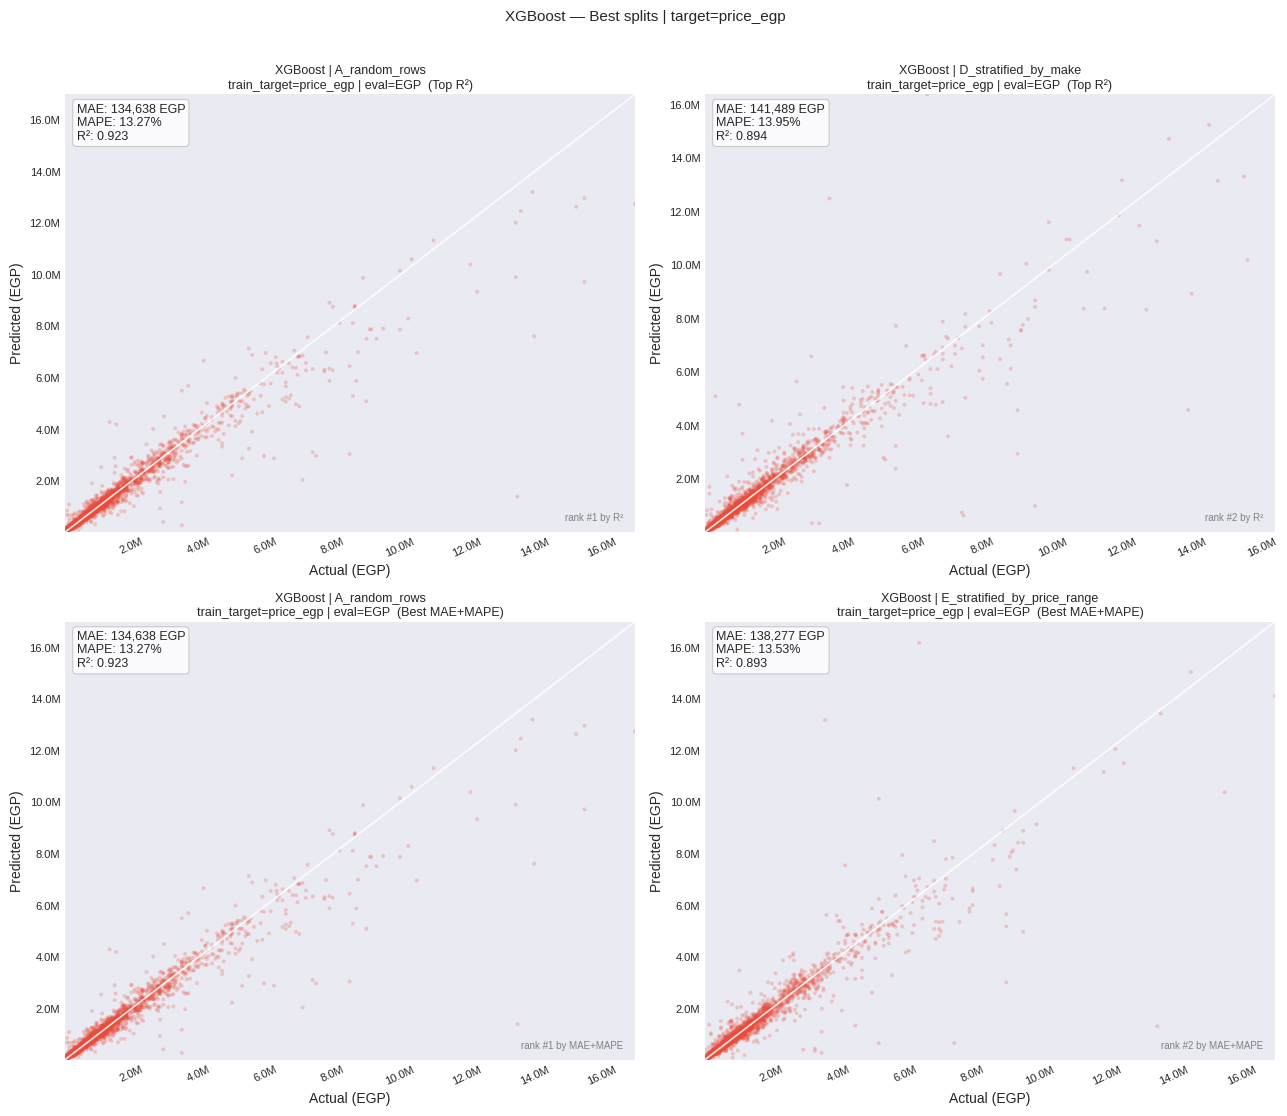


=== LightGBM | target = price_egp_log ===
Top 2 by R²:


,split,MAE,MAPE_pct,R2,Within_15pct
0,A_random_rows,"136,347.651",12.881,0.911,75.563
1,D_stratified_by_make,"145,725.813",13.398,0.878,75.860


Top 2 by lowest MAE+MAPE:


,split,MAE,MAPE_pct,R2,Within_15pct
0,A_random_rows,"136,347.651",12.881,0.911,75.563
1,D_stratified_by_make,"145,725.813",13.398,0.878,75.860


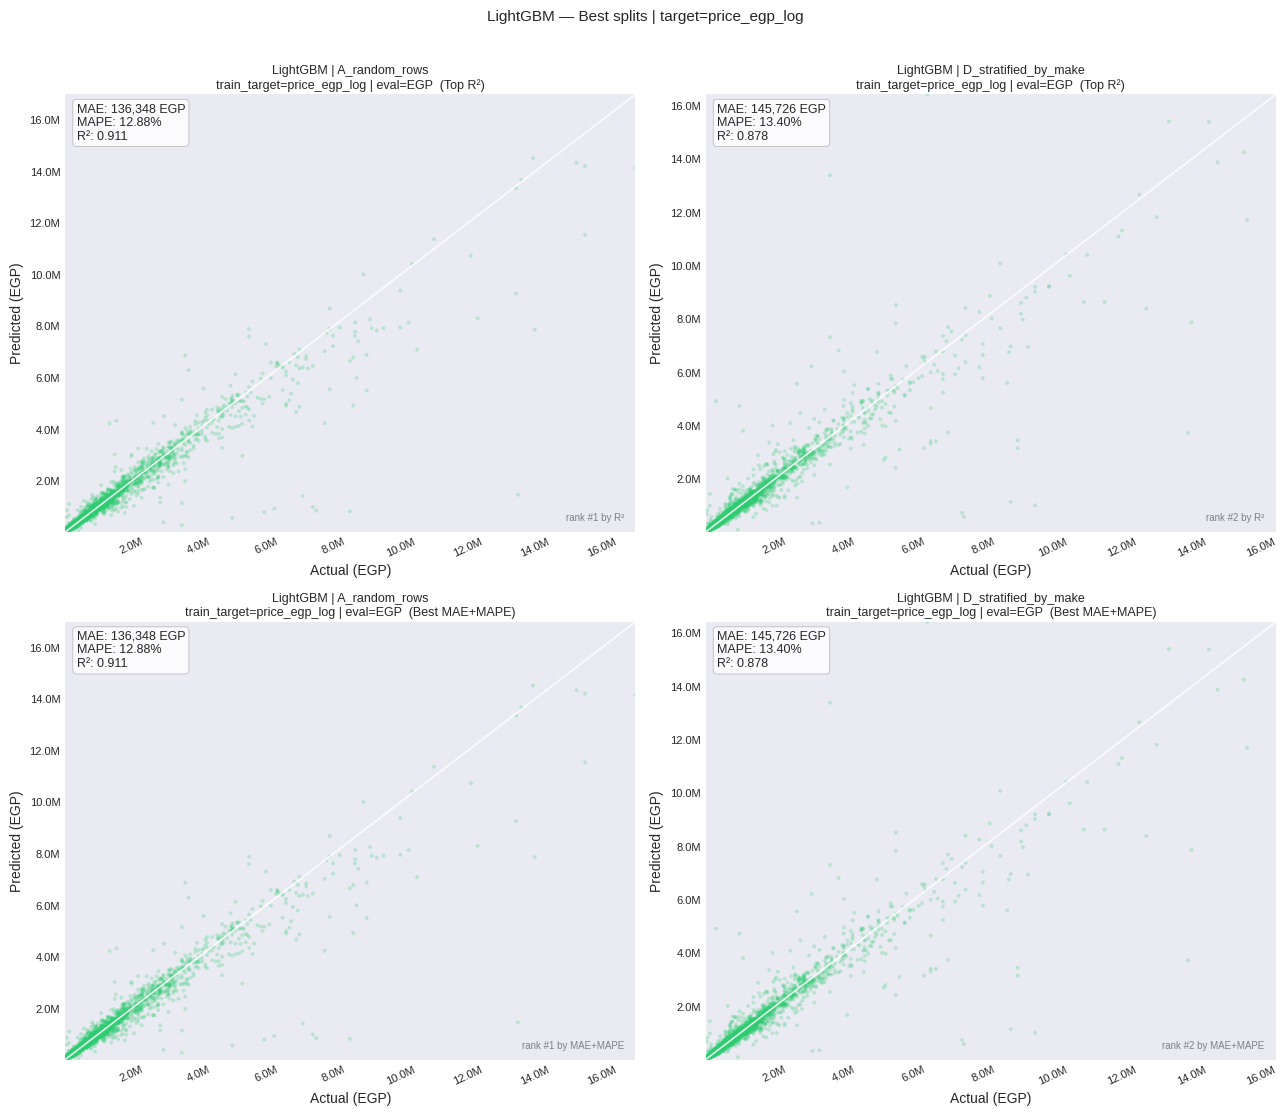


=== XGBoost | target = price_egp_log ===
Top 2 by R²:


,split,MAE,MAPE_pct,R2,Within_15pct
0,A_random_rows,"137,495.509",12.912,0.915,74.351
1,D_stratified_by_make,"139,806.170",13.344,0.895,75.761


Top 2 by lowest MAE+MAPE:


,split,MAE,MAPE_pct,R2,Within_15pct
0,A_random_rows,"137,495.509",12.912,0.915,74.351
1,D_stratified_by_make,"139,806.170",13.344,0.895,75.761


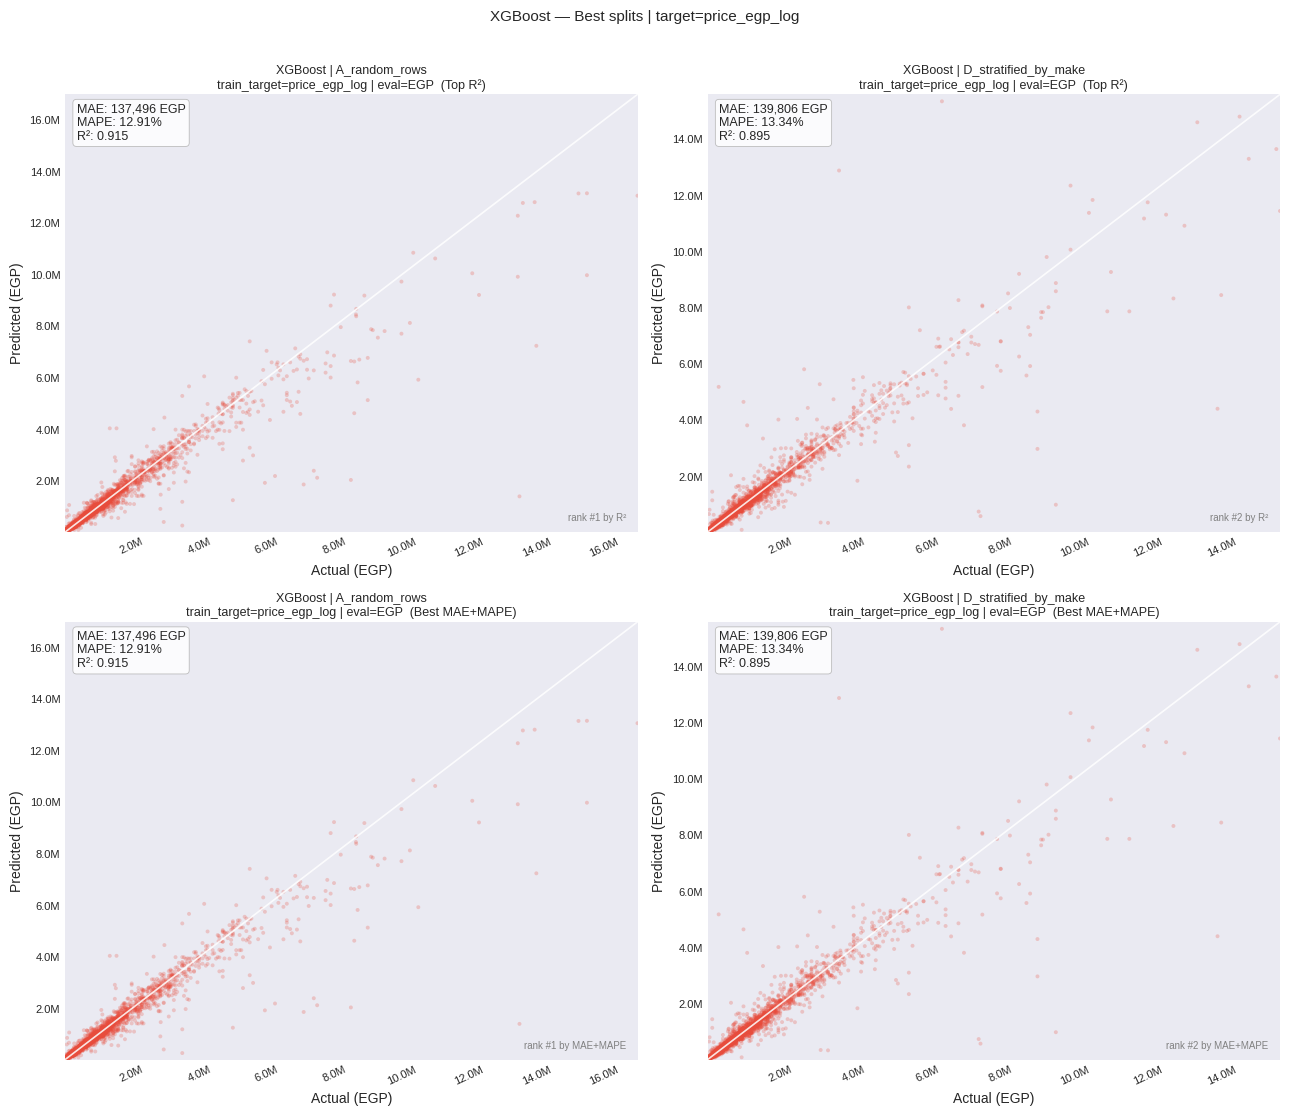

In [37]:
FW_COLORS = {'LightGBM': '#2ecc71', 'XGBoost': '#e74c3c'}

def plot_pred_vs_true(ax, y_true_egp, y_pred_egp, *, title: str, subtitle: str,
                      color: str = 'steelblue'):
    """Scatter plot Predicted vs Actual in EGP — mirrors notebook 04's _plot_pred_vs_true."""
    ax.scatter(y_true_egp, y_pred_egp, s=8, alpha=0.25, edgecolors='none',
               rasterized=True, color=color)
    lo = min(y_true_egp.min(), y_pred_egp.min())
    hi = max(y_true_egp.max(), y_pred_egp.max())
    ax.plot([lo, hi], [lo, hi], color='white', linewidth=1.2, alpha=0.85)
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
    ax.tick_params(axis='x', labelrotation=25, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)
    ax.set_xlabel('Actual (EGP)'); ax.set_ylabel('Predicted (EGP)')
    ax.set_title(f'{title}', fontsize=9, pad=4)

    mae  = float(mean_absolute_error(y_true_egp, y_pred_egp))
    mape = float(np.mean(np.abs((y_true_egp - y_pred_egp) /
                                 np.maximum(np.abs(y_true_egp), 1e-9))) * 100)
    r2   = float(r2_score(y_true_egp, y_pred_egp))
    txt  = f'MAE: {mae:,.0f} EGP\nMAPE: {mape:.2f}%\nR²: {r2:.3f}'
    ax.text(0.02, 0.98, txt, transform=ax.transAxes, va='top', ha='left', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.85, edgecolor='0.7',
                      linewidth=0.6))
    ax.text(0.98, 0.02, subtitle, transform=ax.transAxes, va='bottom', ha='right',
            fontsize=7, color='gray')


# ── Draw 2×2 grids per (target, framework) ────────────────────────────────────
for target in TARGETS_TO_BENCH:
    df_res = results_by_target[target]

    for fw in ['LightGBM', 'XGBoost']:
        cand = df_res[df_res['framework'] == fw].copy().reset_index(drop=True)
        cand['_rank_mae']   = cand['MAE'].rank(method='dense', ascending=True)
        cand['_rank_mape']  = cand['MAPE_pct'].rank(method='dense', ascending=True)
        cand['_rank_score'] = 2.0 * cand['_rank_mae'] + 1.0 * cand['_rank_mape']

        top_r2  = cand.sort_values(['R2', 'MAE'], ascending=[False, True]).head(2)
        top_err = cand.sort_values(['_rank_score', 'MAE', 'MAPE_pct'],
                                    ascending=[True, True, True]).head(2)

        print(f'\n=== {fw} | target = {target} ===')
        print('Top 2 by R²:')
        display(top_r2[['split', 'MAE', 'MAPE_pct', 'R2', 'Within_15pct']].reset_index(drop=True))
        print('Top 2 by lowest MAE+MAPE:')
        display(top_err[['split', 'MAE', 'MAPE_pct', 'R2', 'Within_15pct']].reset_index(drop=True))

        fig, axes = plt.subplots(2, 2, figsize=(13, 11))
        axes = axes.ravel()

        for i, (_, row) in enumerate(top_r2.iterrows()):
            sp   = row['split']
            data = pred_store[target][sp][fw]
            plot_pred_vs_true(
                axes[i], data['y_true_egp'], data['y_pred_egp'],
                title=f'{fw} | {sp}\ntrain_target={target} | eval=EGP  (Top R²)',
                subtitle=f'rank #{i+1} by R²',
                color=FW_COLORS[fw],
            )

        for j, (_, row) in enumerate(top_err.iterrows()):
            sp   = row['split']
            data = pred_store[target][sp][fw]
            plot_pred_vs_true(
                axes[2 + j], data['y_true_egp'], data['y_pred_egp'],
                title=f'{fw} | {sp}\ntrain_target={target} | eval=EGP  (Best MAE+MAPE)',
                subtitle=f'rank #{j+1} by MAE+MAPE',
                color=FW_COLORS[fw],
            )

        plt.suptitle(f'{fw} — Best splits | target={target}',
                     fontsize=11, y=1.01)
        plt.tight_layout()
        plt.savefig(PLOT_DIR / f'best_splits_{fw.lower()}_{target}.png',
                    dpi=120, bbox_inches='tight')
        plt.show()

## 9) Quantile / Confidence-Interval Evaluation

**Checks from doc §03-MODEL-STRATEGY:**
1. **Coverage** — ~80% of test true-prices must fall within [lower, upper]
2. **Monotonicity** — lower ≤ median ≤ upper (clipped post-hoc)
3. **Interval width** — mean relative width 15–30% of median is healthy
4. **No negative lower bound** — clipped to 0

In [38]:
ci_rows = []

for target in TARGETS_TO_BENCH:
    is_log = (target == 'price_egp_log')
    for split_name, (tr_idx, te_idx) in split_indices.items():
        y_te_raw = df_raw.loc[te_idx, target].to_numpy()
        y_te_egp = df_raw.loc[te_idx, 'price_egp'].to_numpy()

        for fw in ['LightGBM', 'XGBoost']:
            mods = (lgbm_store if fw == 'LightGBM' else xgb_store)[target][split_name]

            if fw == 'LightGBM':
                X_te = X_lgbm_all.loc[te_idx]
                lo_raw  = mods['lower'].predict(X_te)
                med_raw = mods['median'].predict(X_te)
                hi_raw  = mods['upper'].predict(X_te)
            else:
                dm = xgb.DMatrix(X_xgb_all.loc[te_idx], enable_categorical=True)
                lo_raw  = mods['lower'].predict(dm)
                med_raw = mods['median'].predict(dm)
                hi_raw  = mods['upper'].predict(dm)

            # Convert to EGP if log-price target
            if is_log:
                med_val = float(np.median(y_te_raw))
                if med_val < 10:  # log10
                    lo_egp, med_egp, hi_egp = np.power(10, lo_raw), np.power(10, med_raw), np.power(10, hi_raw)
                else:             # ln
                    lo_egp, med_egp, hi_egp = np.exp(lo_raw), np.exp(med_raw), np.exp(hi_raw)
            else:
                lo_egp, med_egp, hi_egp = lo_raw, med_raw, hi_raw

            ci = compute_ci_metrics(y_te_egp, lo_egp, med_egp, hi_egp)
            ci_rows.append(dict(train_target=target, framework=fw, split=split_name, **ci))

ci_results = pd.DataFrame(ci_rows).sort_values(['train_target', 'framework', 'split']).reset_index(drop=True)

fmt_ci = ci_results.copy()
fmt_ci['Coverage_pct']    = fmt_ci['Coverage_pct'].apply(lambda x: f'{x:.1f}%')
fmt_ci['Mean_width_pct']  = fmt_ci['Mean_width_pct'].apply(lambda x: f'{x:.1f}%')
display(fmt_ci)

,train_target,framework,split,Coverage_pct,Mono_violations,Mean_width_pct,N_neg_lower
0,price_egp,LightGBM,A_random_rows,79.8%,0,67.1%,0
1,price_egp,LightGBM,B_within_make_model_rows,77.0%,0,60.1%,0
2,price_egp,LightGBM,C_split_by_make_only,28.3%,0,53.9%,0
3,price_egp,LightGBM,D_stratified_by_make,79.2%,0,59.8%,0
4,price_egp,LightGBM,E_stratified_by_price_range,78.4%,0,61.7%,0
5,price_egp,XGBoost,A_random_rows,87.2%,0,82.7%,0
6,price_egp,XGBoost,B_within_make_model_rows,86.4%,0,86.1%,0
7,price_egp,XGBoost,C_split_by_make_only,47.5%,0,82.7%,0
8,price_egp,XGBoost,D_stratified_by_make,86.9%,0,83.7%,0
9,price_egp,XGBoost,E_stratified_by_price_range,87.7%,0,86.5%,0


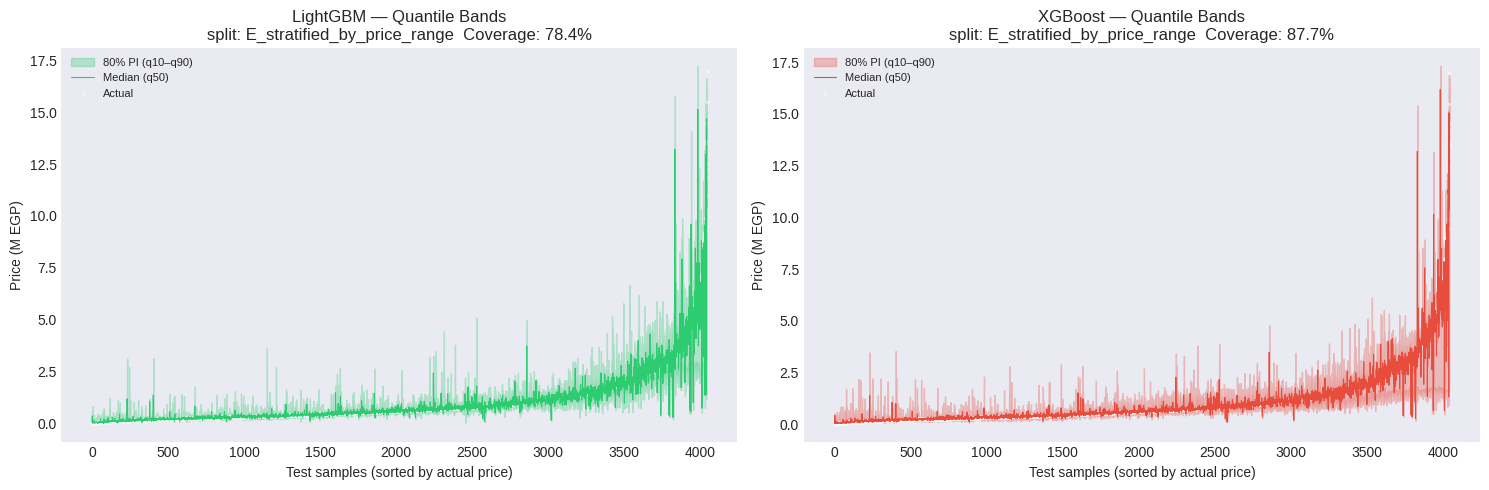

In [39]:
# ── Quantile band plot — best split (TUNE_SPLIT) for each framework & target ──
TARGET_PLOT = 'price_egp'   # always plot raw EGP for readability
is_log_plot = False

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

_, te_plot = split_indices[TUNE_SPLIT]
y_te_egp_plot = df_raw.loc[te_plot, 'price_egp'].to_numpy()

for ax, fw in zip(axes, ['LightGBM', 'XGBoost']):
    mods = (lgbm_store if fw == 'LightGBM' else xgb_store)[TARGET_PLOT][TUNE_SPLIT]

    if fw == 'LightGBM':
        lo  = mods['lower'].predict(X_lgbm_all.loc[te_plot])
        med = mods['median'].predict(X_lgbm_all.loc[te_plot])
        hi  = mods['upper'].predict(X_lgbm_all.loc[te_plot])
    else:
        dm  = xgb.DMatrix(X_xgb_all.loc[te_plot], enable_categorical=True)
        lo  = mods['lower'].predict(dm)
        med = mods['median'].predict(dm)
        hi  = mods['upper'].predict(dm)

    lo  = np.clip(np.minimum(lo,  med), 0, None)
    hi  = np.maximum(hi,  med)

    sort_idx = np.argsort(y_te_egp_plot)
    x_ax     = np.arange(len(sort_idx))

    ax.fill_between(x_ax, lo[sort_idx] / 1e6, hi[sort_idx] / 1e6,
                    alpha=0.3, color=FW_COLORS[fw], label='80% PI (q10–q90)')
    ax.plot(x_ax, med[sort_idx] / 1e6, color=FW_COLORS[fw], lw=0.8, label='Median (q50)')
    ax.scatter(x_ax, y_te_egp_plot[sort_idx] / 1e6, s=3, color='white', alpha=0.4, label='Actual')

    cov = float(np.mean((y_te_egp_plot >= lo) & (y_te_egp_plot <= hi)) * 100)
    ax.set_title(f'{fw} — Quantile Bands\nsplit: {TUNE_SPLIT}  Coverage: {cov:.1f}%')
    ax.set_xlabel('Test samples (sorted by actual price)')
    ax.set_ylabel('Price (M EGP)')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(PLOT_DIR / 'quantile_bands.png', dpi=120, bbox_inches='tight')
plt.show()

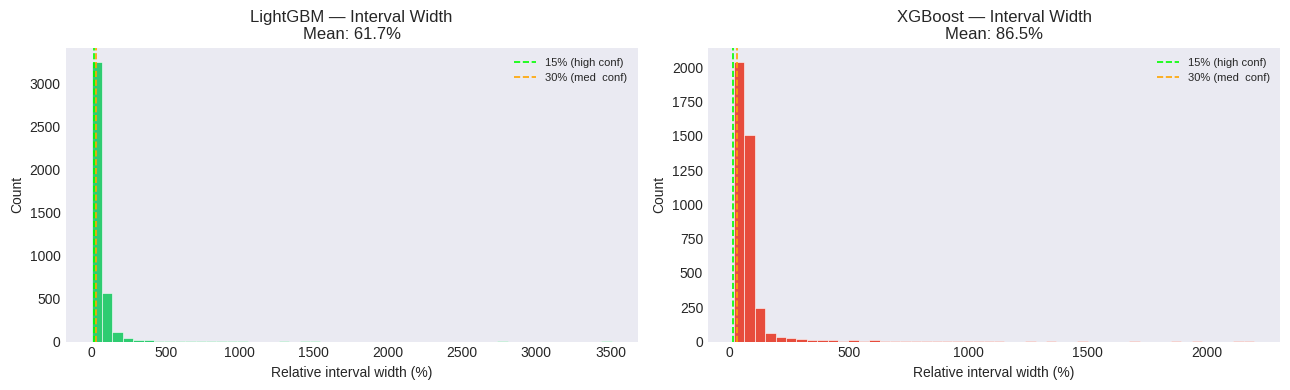

In [40]:
# ── Interval width distribution ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, fw in zip(axes, ['LightGBM', 'XGBoost']):
    mods = (lgbm_store if fw == 'LightGBM' else xgb_store)[TARGET_PLOT][TUNE_SPLIT]

    if fw == 'LightGBM':
        lo  = np.clip(mods['lower'].predict(X_lgbm_all.loc[te_plot]), 0, None)
        med = mods['median'].predict(X_lgbm_all.loc[te_plot])
        hi  = mods['upper'].predict(X_lgbm_all.loc[te_plot])
    else:
        dm  = xgb.DMatrix(X_xgb_all.loc[te_plot], enable_categorical=True)
        lo  = np.clip(mods['lower'].predict(dm), 0, None)
        med = mods['median'].predict(dm)
        hi  = mods['upper'].predict(dm)

    lo  = np.minimum(lo, med)
    hi  = np.maximum(hi, med)
    rel = (hi - lo) / np.maximum(np.abs(med), 1e-9) * 100

    ax.hist(rel, bins=50, color=FW_COLORS[fw], edgecolor='white', lw=0.4)
    ax.axvline(15, color='lime',   ls='--', lw=1.2, label='15% (high conf)')
    ax.axvline(30, color='orange', ls='--', lw=1.2, label='30% (med  conf)')
    ax.set_xlabel('Relative interval width (%)')
    ax.set_ylabel('Count')
    ax.set_title(f'{fw} — Interval Width\nMean: {rel.mean():.1f}%')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(PLOT_DIR / 'interval_width_dist.png', dpi=120, bbox_inches='tight')
plt.show()

## 10) Segmented Evaluation — Per-Brand & Per-Price-Tier

In [65]:
_, te_seg = split_indices[TUNE_SPLIT]
df_te_seg = df_raw.loc[te_seg].copy()

for fw in ['LightGBM', 'XGBoost']:
    mods = (lgbm_store if fw == 'LightGBM' else xgb_store)['price_egp'][TUNE_SPLIT]
    if fw == 'LightGBM':
        df_te_seg[f'pred_{fw}'] = mods['median'].predict(X_lgbm_all.loc[te_seg])
    else:
        dm = xgb.DMatrix(X_xgb_all.loc[te_seg], enable_categorical=True)
        df_te_seg[f'pred_{fw}'] = mods['median'].predict(dm)

def mape_fn(yt, yp):
    return float(np.mean(np.abs((yt - yp) / np.maximum(np.abs(yt), 1e-9))) * 100)

# ── Per-brand ─────────────────────────────────────────────────────────────────
brand_rows = []
for brand, grp in df_te_seg.groupby('make'):
    if len(grp) < 10: continue
    yt = grp['price_egp'].values
    brand_rows.append(dict(
        brand      = brand, n_test = len(grp),
        LGBM_MAPE  = mape_fn(yt, grp['pred_LightGBM'].values),
        XGB_MAPE   = mape_fn(yt, grp['pred_XGBoost'].values),
        LGBM_R2    = r2_score(yt, grp['pred_LightGBM'].values),
        XGB_R2     = r2_score(yt, grp['pred_XGBoost'].values),
    ))
brand_seg = pd.DataFrame(brand_rows).sort_values('LGBM_MAPE').reset_index(drop=True)
print(f'Per-brand evaluation ({len(brand_seg)} brands with ≥5 test rows):')
display(brand_seg.head(20))



Per-brand evaluation (42 brands with ≥5 test rows):


,brand,n_test,LGBM_MAPE,XGB_MAPE,LGBM_R2,XGB_R2
0,Cupra,13,2.932,3.838,0.886,0.763
1,Citroën,56,8.792,7.851,0.959,0.961
2,Nissan,175,9.104,9.101,0.889,0.908
3,Speranza,65,9.265,10.400,0.876,0.823
4,JAC,16,9.374,8.758,0.888,0.894
5,BAIC,18,9.497,13.276,0.900,0.868
6,Haval,12,9.611,8.917,0.317,0.361
7,Renault,259,9.810,10.112,0.910,0.913
8,Jetour,19,9.994,9.211,0.776,0.757
9,Proton,26,10.212,11.231,0.883,0.859


In [78]:
# ── Per-Price-Tier Evaluation ─────────────────────────────────────────────────
price_bins = [0, 300_000, 600_000, 1_000_000, 2_000_000, 5_000_000, float('inf')]
price_labels = [
    'Economy (< 300k)',        # Lanos, Peugeot 206, old Fiat
    'Mid-range (300–600k)',    # Hyundai Accent, BYD F3, Chevrolet Aveo
    'Upper-mid (600k–1M)',     # Kia Cerato, Renault Logan, VW Polo
    'Premium (1–2M)',          # Toyota Corolla new, Chery Tiggo 8
    'Luxury (2–5M)',           # BMW 3 Series, Mercedes C-Class
    'Ultra-luxury (5M+)'       # Porsche, Range Rover, G63
]

df_te_seg['price_tier'] = pd.cut(df_te_seg['price_egp'], bins=price_bins, labels=price_labels, right=False)

tier_rows = []
for tier, grp in df_te_seg.groupby('price_tier', observed=True):
    if len(grp) < 3: continue
    yt = grp['price_egp'].values
    for fw in ['LightGBM', 'XGBoost']:
        yp = grp[f'pred_{fw}'].values
        resid = yt - yp
        tier_rows.append(dict(
            price_tier = tier, framework = fw,
            MAE        = float(mean_absolute_error(yt, yp)),
            RMSE       = float(np.sqrt(mean_squared_error(yt, yp))),
            R2         = float(r2_score(yt, yp)) if len(grp) > 2 else np.nan,
            MAPE_pct   = mape_fn(yt, yp),
        ))

df_tier = pd.DataFrame(tier_rows)
display(df_tier.pivot(index='price_tier', columns='framework',
                      values=['MAE','MAPE_pct','R2']).round(2))

MAE               MAPE_pct               R2  \
framework                 LightGBM       XGBoost LightGBM XGBoost LightGBM   
price_tier                                                                   
Economy (< 300k)        35,114.250    35,991.060   22.020  22.650   -0.350   
Luxury (2–5M)          404,434.390   375,972.470   13.140  12.210   -0.060   
Mid-range (300–600k)    47,538.100    47,546.500   11.000  11.100   -0.020   
Premium (1–2M)         148,789.640   146,475.310   10.590  10.500    0.260   
Ultra-luxury (5M+)   1,469,828.690 1,274,469.000   19.940  17.260   -0.060   
Upper-mid (600k–1M)     80,637.730    79,083.800   10.480  10.250   -0.690   

                              
framework            XGBoost  
price_tier                    
Economy (< 300k)      -0.270  
Luxury (2–5M)         -0.000  
Mid-range (300–600k)   0.020  
Premium (1–2M)         0.310  
Ultra-luxury (5M+)     0.090  
Upper-mid (600k–1M)   -0.670

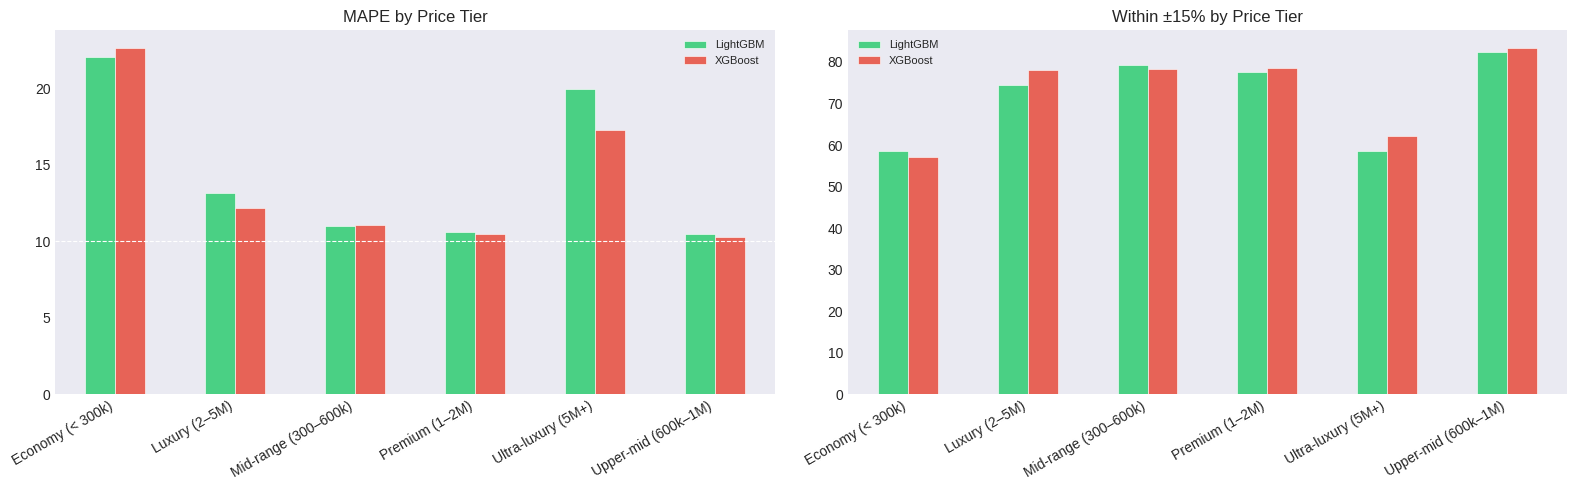

In [43]:
# ── Price-tier MAPE + Within-15% visualisation ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, metric, title in [(axes[0], 'MAPE_pct', 'MAPE by Price Tier'),
                           (axes[1], 'Within_15', 'Within ±15% by Price Tier')]:
    pivot = df_tier.pivot(index='price_tier', columns='framework', values=metric)
    pivot.plot.bar(ax=ax, color=['#2ecc71', '#e74c3c'], alpha=0.85, edgecolor='white', lw=0.5)
    ax.set_title(title); ax.set_xlabel(''); ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
    if metric == 'MAPE_pct': ax.axhline(10, color='white', ls='--', lw=0.8)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(PLOT_DIR / 'price_tier_metrics.png', dpi=120, bbox_inches='tight')
plt.show()

In [44]:
# ── Per-Make × Price-Tier Cross-Tabulation ─────────────────────────────────────
# Show how each brand performs across different price segments
IMPORTANT_BRANDS = ['Chevrolet', 'Hyundai', 'Kia', 'Toyota', 'BMW', 'Mercedes',
                    'Chery', 'Daewoo', 'Skoda', 'Nissan', 'Renault', 'Volkswagen',
                    'Peugeot', 'MG', 'Opel', 'Fiat', 'BYD', 'Seat']

fw_best = 'LightGBM'  # or 'XGBoost' — change based on winner
cross_rows = []
for brand in IMPORTANT_BRANDS:
    grp_brand = df_te_seg[df_te_seg['make'] == brand]
    if len(grp_brand) < 5: continue
    for tier in price_labels:
        grp = grp_brand[grp_brand['price_tier'] == tier]
        if len(grp) < 3: continue
        yt = grp['price_egp'].values
        yp = grp[f'pred_{fw_best}'].values
        cross_rows.append(dict(
            make = brand, price_tier = tier, n = len(grp),
            MAPE_pct = mape_fn(yt, yp),
            R2 = float(r2_score(yt, yp)) if len(grp) > 2 else np.nan,
            Within_10 = float(np.mean(np.abs((yt - yp) / np.maximum(np.abs(yt), 1e-9)) <= 0.10) * 100),
        ))

df_cross = pd.DataFrame(cross_rows)
if len(df_cross) > 0:
    display(df_cross.pivot(index='make', columns='price_tier', values='MAPE_pct').round(1)
            .reindex(columns=price_labels).fillna('—'))
    print(f'\nCross-tab uses {fw_best} predictions. Brands with <3 samples in a tier are omitted.')
else:
    print('Not enough data for cross-tabulation.')

price_tier,Economy (< 300k),Mid-range (300–600k),Upper-mid (600k–1M),Premium (1–2M),Luxury (2–5M),Ultra-luxury (5M+)
make,,,,,,
BMW,—,9.700,18.100,9.800,14.700,6.100
BYD,14.800,9.900,33.000,13.800,29.600,—
Chery,21.200,12.200,5.800,18.200,—,—
Chevrolet,46.500,7.700,12.500,16.500,—,84.700
Daewoo,14.300,7.400,—,—,—,—
Fiat,20.800,11.900,5.700,8.600,—,—
Hyundai,20.900,9.600,13.400,8.800,19.100,—
Kia,16.100,7.500,10.500,12.700,12.700,—
MG,—,—,8.700,4.900,—,—



Cross-tab uses LightGBM predictions. Brands with <3 samples in a tier are omitted.


In [73]:
# ── Per-Model (make+model) Diagnostics ─────────────────────────────────────────
model_rows = []
for (brand, mdl), grp in df_te_seg.groupby(['make', 'model']):
    if len(grp) < 5: continue
    yt = grp['price_egp'].values
    for fw in ['LightGBM', 'XGBoost']:
        yp = grp[f'pred_{fw}'].values
        model_rows.append(dict(
            make = brand, model = mdl, n = len(grp), framework = fw,
            MAPE_pct = mape_fn(yt, yp),
            R2 = float(r2_score(yt, yp)) if len(grp) > 2 else np.nan,
            MAE = float(mean_absolute_error(yt, yp)),
            mean_price = float(np.mean(yt)),
        ))

df_model_diag = pd.DataFrame(model_rows)
# Show worst-performing models (highest MAPE)
worst = df_model_diag[df_model_diag['framework'] == fw_best].nlargest(25, 'MAPE_pct')
print(f'Top 25 worst models by MAPE ({fw_best}, min 20 test rows):')
display(worst[['make','model','n','mean_price','MAPE_pct','R2','MAE']].round(1))

# Show best-performing models
best = df_model_diag[df_model_diag['framework'] == fw_best].nsmallest(15, 'MAPE_pct')
print(f'\nTop 15 best models by MAPE ({fw_best}):')
display(best[['make','model','n','mean_price','MAPE_pct','R2','MAE']].round(1))

Top 25 worst models by MAPE (LightGBM, min 20 test rows):


,make,model,n,mean_price,MAPE_pct,R2,MAE
56,Chevrolet,Avalanche,7,"473,571.400",128.300,-1.500,"290,047.500"
236,Mercedes,200,9,"568,888.900",55.300,0.800,"230,715.100"
336,Porsche,Cayenne,6,"5,966,666.700",52.900,0.800,"1,135,356.000"
218,Land Rover,Range Rover Vogue,7,"7,742,857.000",51.600,0.300,"2,308,345.200"
338,Porsche,Cayenne S,7,"5,757,142.900",49.300,0.700,"1,200,617.800"
126,Honda,Accord,7,"1,047,142.900",45.900,0.900,"125,327.000"
260,Mercedes,G63,5,"9,840,000.000",34.800,-0.600,"2,393,363.200"
396,SsangYong,Tivoli,5,"784,000.000",33.500,-0.800,"196,467.400"
252,Mercedes,E200,40,"3,411,250.000",33.400,0.900,"371,686.600"
270,Mercedes,GLS,6,"6,825,000.000",32.200,-3.300,"2,215,336.700"



Top 15 best models by MAPE (LightGBM):


,make,model,n,mean_price,MAPE_pct,R2,MAE
178,Jetour,T2,5,"1,811,000.000",2.300,0.900,"40,759.900"
82,Cupra,Leon,5,"1,687,000.000",2.700,0.800,"43,990.900"
286,Mitsubishi,Xpander,7,"1,146,428.600",3.200,0.900,"37,801.600"
50,Chery,Tiggo 7,11,"825,272.700",3.400,0.900,"28,199.700"
344,Proton,Saga,8,"434,375.000",3.400,1.000,"17,320.700"
394,Speranza,Tiggo,5,"440,800.000",3.600,1.000,"13,157.200"
54,Chery,Tiggo 8,6,"1,077,500.000",4.200,0.700,"42,369.000"
294,Nissan,Sentra,20,"708,475.000",4.300,0.900,"29,024.000"
228,MG,RX5,16,"1,040,625.000",4.400,1.000,"42,695.200"
20,BMW,X1,12,"1,782,083.300",4.400,1.000,"71,765.400"


In [74]:
# ── Per-Model (make+model) Diagnostics ─────────────────────────────────────────
model_rows = []
for (brand, mdl), grp in df_te_seg.groupby(['make', 'model']):
    if len(grp) < 5:
        continue

    yt = grp['price_egp'].values
    yp = grp['pred_XGBoost'].values

    model_rows.append(dict(
        make=brand,
        model=mdl,
        n=len(grp),
        framework='XGBoost',
        MAPE_pct=mape_fn(yt, yp),
        R2=float(r2_score(yt, yp)) if len(grp) > 2 else np.nan,
        MAE=float(mean_absolute_error(yt, yp)),
        mean_price=float(np.mean(yt)),
    ))

df_model_diag = pd.DataFrame(model_rows)

# Show worst-performing models (highest MAE)
worst = df_model_diag.nlargest(35, 'MAPE_pct')
print('Top 25 worst models by MAPE (XGBoost, min 20 test rows):')
display(worst[['make', 'model', 'n', 'mean_price', 'MAPE_pct', 'R2', 'MAE']].round(1))

# Show best-performing models
best = df_model_diag.nsmallest(20, 'MAPE_pct')
print('\nTop 15 best models by MAPE (XGBoost):')
display(best[['make', 'model', 'n', 'mean_price', 'MAPE_pct', 'R2', 'MAE']].round(1))

Top 25 worst models by MAPE (XGBoost, min 20 test rows):


,make,model,n,mean_price,MAPE_pct,R2,MAE
28,Chevrolet,Avalanche,7,"473,571.400",130.300,-1.900,"233,235.300"
118,Mercedes,200,9,"568,888.900",51.900,0.900,"224,408.500"
109,Land Rover,Range Rover Vogue,7,"7,742,857.000",50.900,0.300,"2,346,739.800"
168,Porsche,Cayenne,6,"5,966,666.700",49.000,0.900,"1,087,246.500"
63,Honda,Accord,7,"1,047,142.900",48.300,0.900,"128,781.900"
169,Porsche,Cayenne S,7,"5,757,142.900",43.300,0.800,"1,024,766.400"
54,Ford,Bronco Raptor,10,"192,000.000",41.700,-6.300,"92,965.600"
130,Mercedes,G63,5,"9,840,000.000",36.500,-1.000,"2,550,350.000"
51,Fiat,Shahin,11,"108,000.000",33.300,-0.000,"31,155.800"
198,SsangYong,Tivoli,5,"784,000.000",33.100,-0.700,"193,143.100"



Top 15 best models by MAPE (XGBoost):


,make,model,n,mean_price,MAPE_pct,R2,MAE
89,Jetour,T2,5,"1,811,000.000",1.200,1.000,"21,909.400"
41,Cupra,Leon,5,"1,687,000.000",2.700,0.700,"42,931.400"
197,Speranza,Tiggo,5,"440,800.000",2.700,1.000,"12,101.200"
27,Chery,Tiggo 8,6,"1,077,500.000",3.300,0.800,"35,040.600"
108,Land Rover,Range Rover Velar,6,"4,341,666.700",3.400,1.000,"144,153.400"
13,BMW,X6,7,"6,014,285.700",3.700,0.700,"223,519.000"
143,Mitsubishi,Xpander,7,"1,146,428.600",3.700,0.900,"42,964.000"
147,Nissan,Sentra,20,"708,475.000",3.800,0.900,"25,322.900"
30,Chevrolet,Captiva,8,"959,375.000",4.100,0.900,"36,544.600"
114,MG,RX5,16,"1,040,625.000",4.400,1.000,"45,625.900"


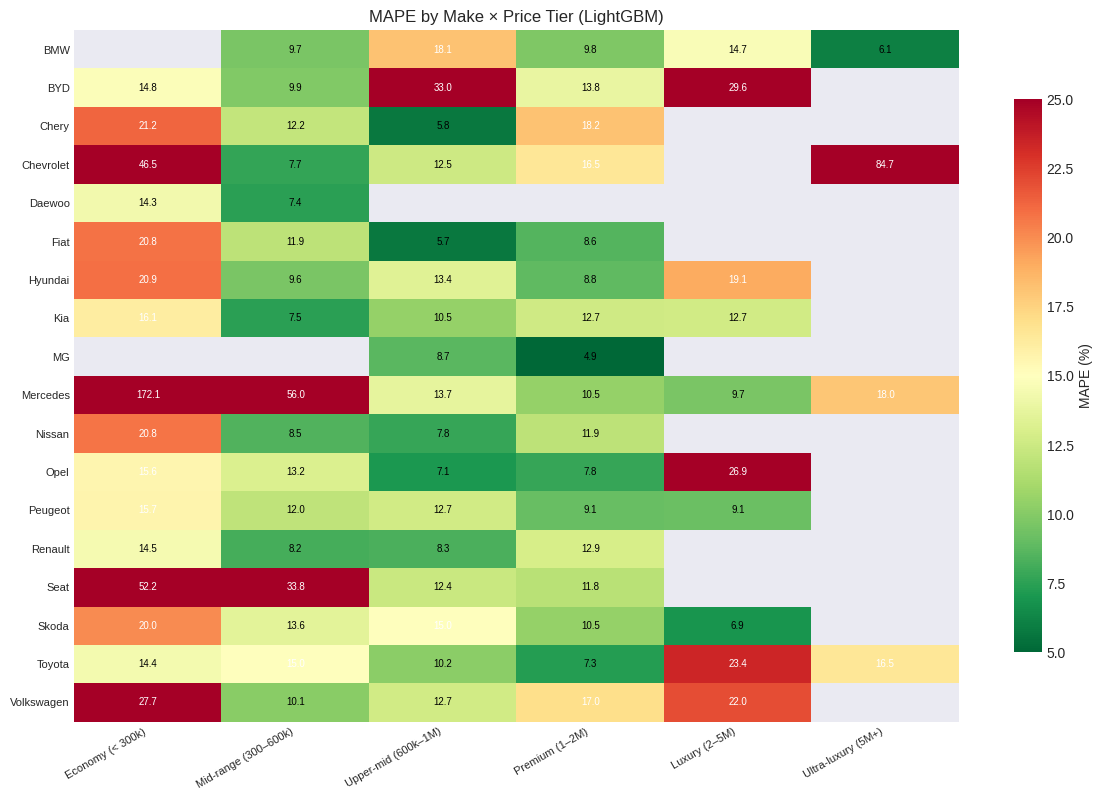

In [69]:
# ── Heatmap: MAPE by Make × Price Tier ────────────────────────────────────────
if len(df_cross) > 0:
    pivot_hm = df_cross.pivot(index='make', columns='price_tier', values='MAPE_pct').reindex(columns=price_labels)
    # Only show makes that have at least 2 tiers with data
    valid_makes = pivot_hm.dropna(thresh=2, axis=0).index
    if len(valid_makes) > 0:
        pivot_hm = pivot_hm.loc[valid_makes]
        fig, ax = plt.subplots(figsize=(12, max(4, len(valid_makes) * 0.45)))
        im = ax.imshow(pivot_hm.values, aspect='auto', cmap='RdYlGn_r', vmin=5, vmax=25)
        ax.set_xticks(range(len(price_labels))); ax.set_xticklabels(price_labels, rotation=30, ha='right', fontsize=8)
        ax.set_yticks(range(len(valid_makes))); ax.set_yticklabels(valid_makes, fontsize=8)
        # Annotate cells
        for i in range(len(valid_makes)):
            for j in range(len(price_labels)):
                v = pivot_hm.values[i, j]
                if not np.isnan(v):
                    ax.text(j, i, f'{v:.1f}', ha='center', va='center', fontsize=7,
                            color='white' if v > 15 else 'black')
        plt.colorbar(im, ax=ax, label='MAPE (%)', shrink=0.8)
        ax.set_title(f'MAPE by Make × Price Tier ({fw_best})')
        plt.tight_layout()
        plt.savefig(PLOT_DIR / 'make_price_tier_heatmap.png', dpi=120, bbox_inches='tight')
        plt.show()
    else:
        print('Not enough brands with multi-tier data for heatmap.')
else:
    print('No cross-tab data available for heatmap.')

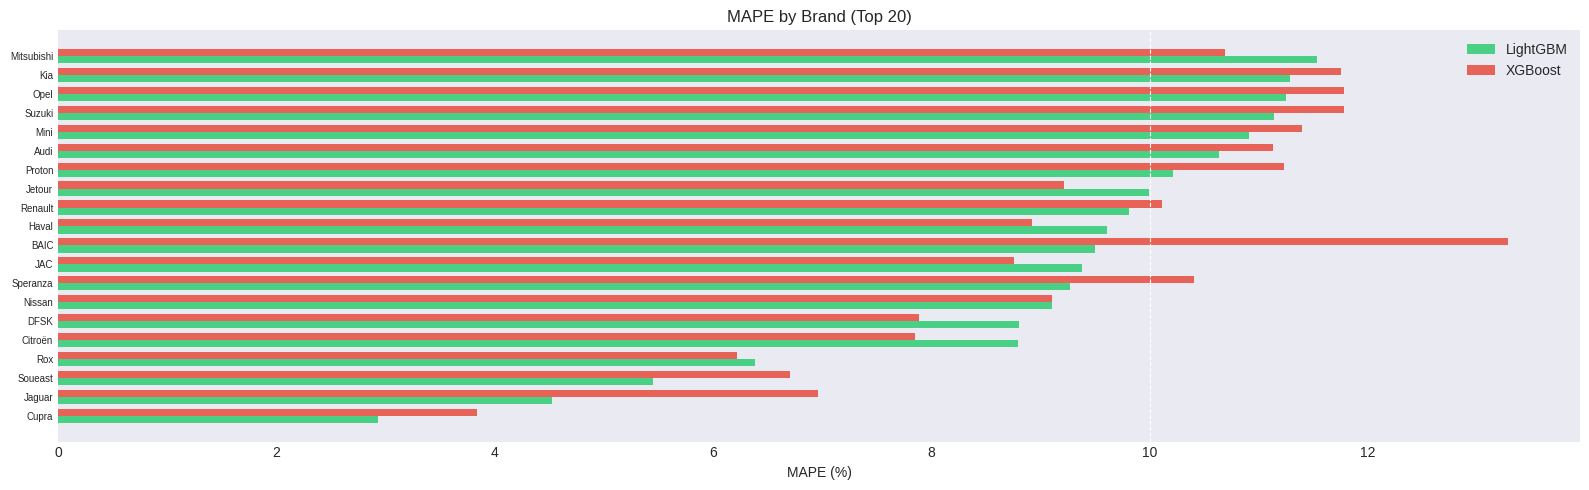

In [47]:
# ── Visual: brand MAPE + price-tier MAPE ─────────────────────────────────────
top20 = brand_seg.sort_values('LGBM_MAPE').head(20)
fig, axes = plt.subplots(1, 1, figsize=(16, 5))

x = np.arange(len(top20)); w = 0.38
axes.barh(x - w/2, top20['LGBM_MAPE'], height=0.38, color='#2ecc71', alpha=0.85, label='LightGBM')
axes.barh(x + w/2, top20['XGB_MAPE'],  height=0.38, color='#e74c3c', alpha=0.85, label='XGBoost')
axes.axvline(10, color='white', ls='--', lw=0.8)
axes.set_yticks(x); axes.set_yticklabels(top20['brand'], fontsize=7)
axes.set_xlabel('MAPE (%)'); axes.set_title('MAPE by Brand (Top 20)')
axes.legend()


plt.tight_layout()
plt.savefig(PLOT_DIR / 'segmented_mape.png', dpi=120, bbox_inches='tight')
plt.show()

## 11) 5-Fold Cross-Validation (Median Model)

Per **doc §03**: Run 5-fold CV on the median model — this is the **official GP defense accuracy number**.

In [48]:
CV_FOLDS = 5
kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

cv_results: dict[str, list] = {fw: [] for fw in ['LightGBM', 'XGBoost']}

y_cv = df_raw['price_egp'].to_numpy()

for fold, (tr_f, te_f) in enumerate(kf.split(X_lgbm_all)):
    print(f'Fold {fold+1}/{CV_FOLDS}')

    # inner val for early stopping
    rng_f   = np.random.default_rng(RANDOM_STATE + fold)
    val_n_f = max(1, int(len(tr_f) * 0.10))
    v_f     = rng_f.choice(tr_f, size=val_n_f, replace=False)
    t_f     = np.array([i for i in tr_f if i not in set(v_f.tolist())])

    # ── LightGBM ──
    dt_l = lgb.Dataset(X_lgbm_all.iloc[t_f], label=y_cv[t_f],
                        categorical_feature=CAT_COLS, free_raw_data=False)
    dv_l = lgb.Dataset(X_lgbm_all.iloc[v_f], label=y_cv[v_f],
                        categorical_feature=CAT_COLS, free_raw_data=False, reference=dt_l)
    p_l  = {**LGBM_BEST, 'objective': 'quantile', 'alpha': 0.5, 'metric': 'quantile',
            'verbosity': -1, 'n_jobs': -1, 'seed': RANDOM_STATE, 'subsample_freq': 1}
    m_l  = lgb.train(p_l, dt_l, num_boost_round=N_ESTIMATORS_MAX, valid_sets=[dv_l],
                      callbacks=[lgb.early_stopping(EARLY_STOPPING_ROUNDS, verbose=False),
                                 lgb.log_evaluation(-1)])
    pred_l = m_l.predict(X_lgbm_all.iloc[te_f])
    met_l  = compute_metrics_egp(y_cv[te_f], pred_l)
    met_l.pop('_y_true_egp', None); met_l.pop('_y_pred_egp', None)
    cv_results['LightGBM'].append(met_l)
    print(f'  LightGBM  MAE={met_l["MAE"]:,.0f}  MAPE={met_l["MAPE_pct"]:.2f}%  R²={met_l["R2"]:.4f}')

    # ── XGBoost ──
    dm_t = xgb.DMatrix(X_xgb_all.iloc[t_f], label=y_cv[t_f], enable_categorical=True)
    dm_v = xgb.DMatrix(X_xgb_all.iloc[v_f], label=y_cv[v_f], enable_categorical=True)
    dm_e = xgb.DMatrix(X_xgb_all.iloc[te_f], enable_categorical=True)
    p_x  = {**XGB_BEST, 'objective': 'reg:quantileerror', 'quantile_alpha': 0.5,
            'eval_metric': 'quantile', 'tree_method': 'hist', 'device': 'cpu',
            'seed': RANDOM_STATE, 'nthread': -1, 'verbosity': 0}
    m_x  = xgb.train(p_x, dm_t, num_boost_round=N_ESTIMATORS_MAX,
                      evals=[(dm_v, 'val')], early_stopping_rounds=EARLY_STOPPING_ROUNDS,
                      verbose_eval=False)
    pred_x = m_x.predict(dm_e)
    met_x  = compute_metrics_egp(y_cv[te_f], pred_x)
    met_x.pop('_y_true_egp', None); met_x.pop('_y_pred_egp', None)
    cv_results['XGBoost'].append(met_x)
    print(f'  XGBoost   MAE={met_x["MAE"]:,.0f}  MAPE={met_x["MAPE_pct"]:.2f}%  R²={met_x["R2"]:.4f}')

print('\n--- CV Summary ---')
for fw, fold_metrics in cv_results.items():
    for k in ['MAE', 'MAPE_pct', 'R2']:
        vals = np.array([m[k] for m in fold_metrics])
        print(f'  {fw:<12} {k:<12} mean={vals.mean():.4f}  std={vals.std():.4f}')

Fold 1/5
  LightGBM  MAE=143,108  MAPE=13.70%  R²=0.9032
  XGBoost   MAE=136,350  MAPE=13.15%  R²=0.9194
Fold 2/5
  LightGBM  MAE=148,024  MAPE=14.00%  R²=0.8561
  XGBoost   MAE=139,380  MAPE=13.84%  R²=0.8716
Fold 3/5
  LightGBM  MAE=157,297  MAPE=15.57%  R²=0.8499
  XGBoost   MAE=147,406  MAPE=15.39%  R²=0.8823
Fold 4/5
  LightGBM  MAE=161,390  MAPE=15.86%  R²=0.7923
  XGBoost   MAE=151,592  MAPE=15.74%  R²=0.8147
Fold 5/5
  LightGBM  MAE=141,489  MAPE=15.36%  R²=0.9302
  XGBoost   MAE=131,706  MAPE=14.58%  R²=0.9414

--- CV Summary ---
  LightGBM     MAE          mean=150261.6693  std=7829.3136
  LightGBM     MAPE_pct     mean=14.8978  std=0.8765
  LightGBM     R2           mean=0.8664  std=0.0475
  XGBoost      MAE          mean=141286.7592  std=7258.6226
  XGBoost      MAPE_pct     mean=14.5404  std=0.9559
  XGBoost      R2           mean=0.8859  std=0.0436


## 12) Optuna Convergence & Hyperparameter Importance

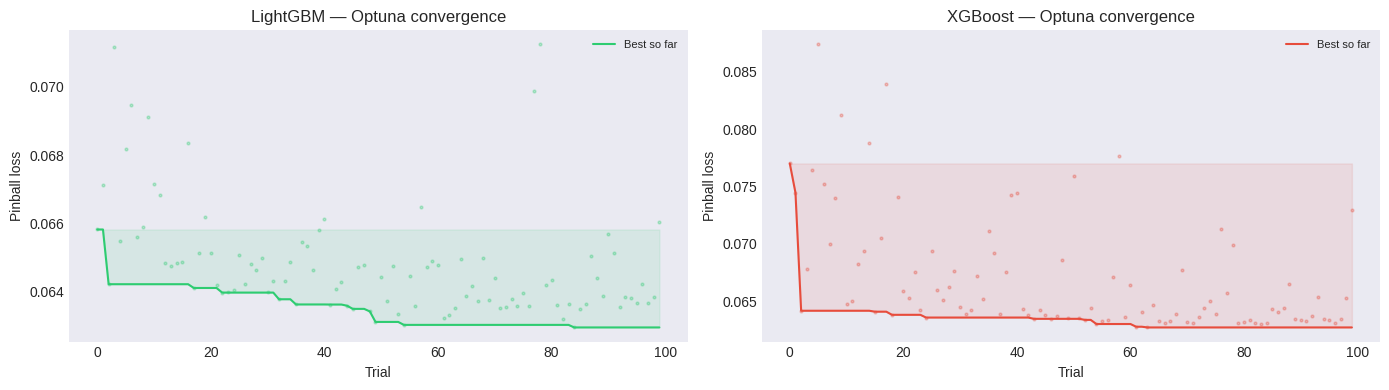

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (study, fw) in zip(axes, [(lgbm_study, 'LightGBM'), (xgb_study, 'XGBoost')]):
    vals = [t.value for t in study.trials if t.value is not None]
    best_so_far = np.minimum.accumulate(vals)
    ax.plot(best_so_far, color=FW_COLORS[fw], lw=1.5, label='Best so far')
    ax.fill_between(range(len(best_so_far)), best_so_far, float(max(best_so_far)),
                    alpha=0.1, color=FW_COLORS[fw])
    ax.scatter(range(len(vals)), vals, s=4, alpha=0.3, color=FW_COLORS[fw])
    ax.set_xlabel('Trial'); ax.set_ylabel('Pinball loss')
    ax.set_title(f'{fw} — Optuna convergence')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(PLOT_DIR / 'optuna_convergence.png', dpi=120, bbox_inches='tight')
plt.show()

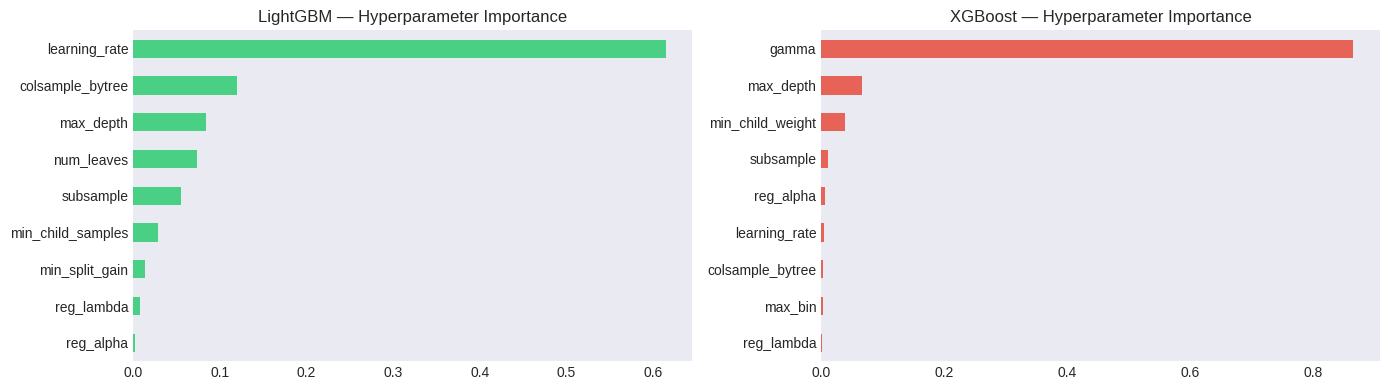

In [50]:
try:
    from optuna.importance import get_param_importances
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for ax, (study, fw) in zip(axes, [(lgbm_study, 'LightGBM'), (xgb_study, 'XGBoost')]):
        imp = get_param_importances(study)
        pd.Series(imp).sort_values().plot.barh(ax=ax, color=FW_COLORS[fw], alpha=0.85)
        ax.set_title(f'{fw} — Hyperparameter Importance')
    plt.tight_layout()
    plt.savefig(PLOT_DIR / 'optuna_param_importance.png', dpi=120, bbox_inches='tight')
    plt.show()
except Exception as e:
    print('Param importance skipped:', e)

## 13) SHAP Analysis

Using the **LightGBM median model on TUNE_SPLIT** test set, per **doc §03 — Explainability**.

In [51]:
_, te_shap = split_indices[TUNE_SPLIT]

# LightGBM SHAP
lgbm_med = lgbm_store['price_egp'][TUNE_SPLIT]['median']
X_shap   = X_lgbm_all.loc[te_shap].copy()
for c in CAT_COLS:
    X_shap[c] = pd.Categorical(
        X_shap[c],
        categories=X_lgbm_all[c].cat.categories,
        ordered=X_lgbm_all[c].cat.ordered,
    )

print('Computing SHAP values (LightGBM median) ...')
lgbm_expl  = shap.TreeExplainer(lgbm_med)
lgbm_sv    = lgbm_expl.shap_values(X_shap)
print('SHAP values shape:', np.array(lgbm_sv).shape)

Computing SHAP values (LightGBM median) ...
SHAP values shape: (4043, 15)


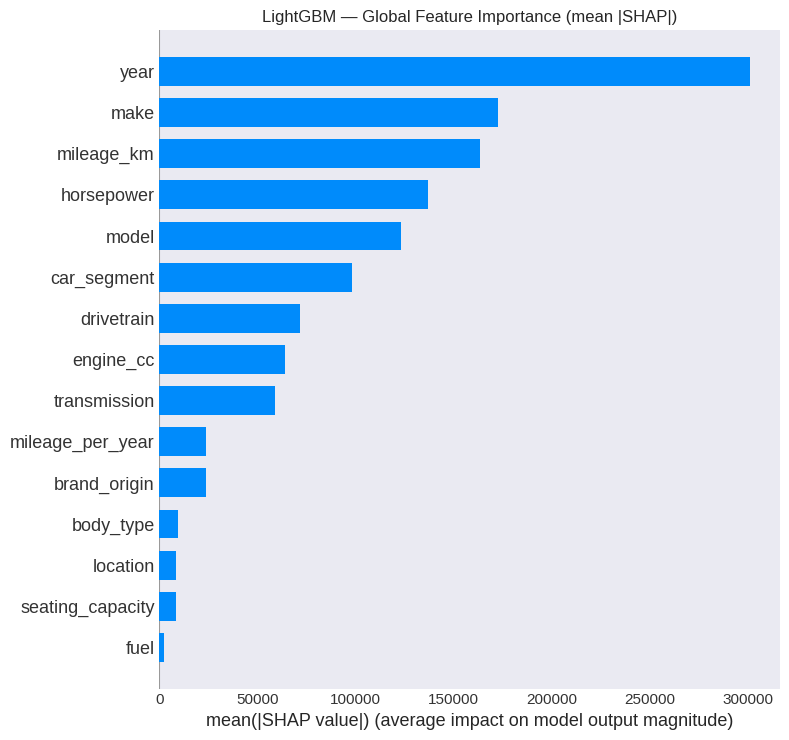

In [52]:
# ── Global bar ────────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 6))
shap.summary_plot(lgbm_sv, X_shap, plot_type='bar', show=False, max_display=20)
plt.title('LightGBM — Global Feature Importance (mean |SHAP|)')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'shap_summary.png', dpi=120, bbox_inches='tight')
plt.show()

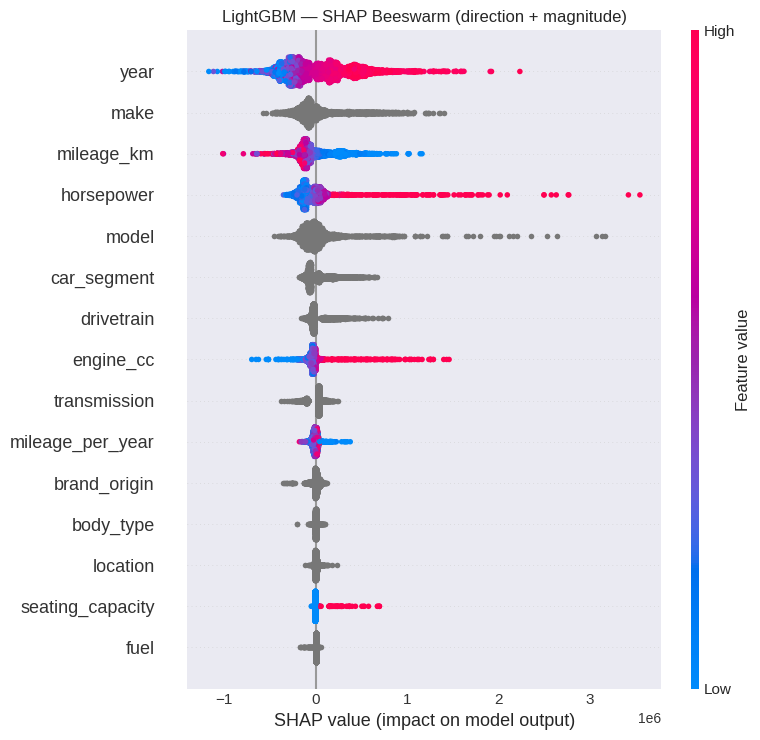

In [53]:
# ── Beeswarm ──────────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 6))
shap.summary_plot(lgbm_sv, X_shap, show=False, max_display=15)
plt.title('LightGBM — SHAP Beeswarm (direction + magnitude)')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'shap_beeswarm.png', dpi=120, bbox_inches='tight')
plt.show()

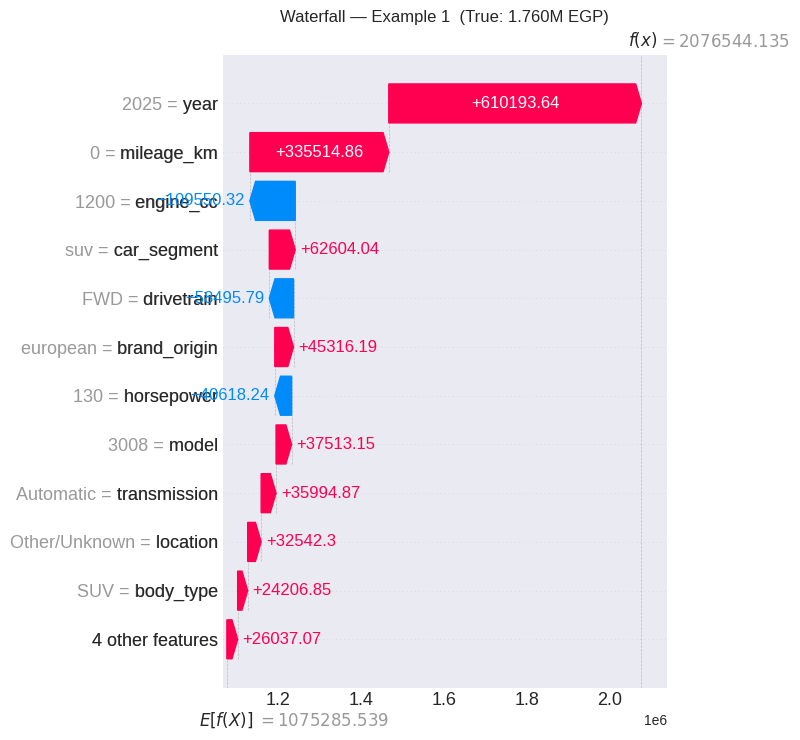

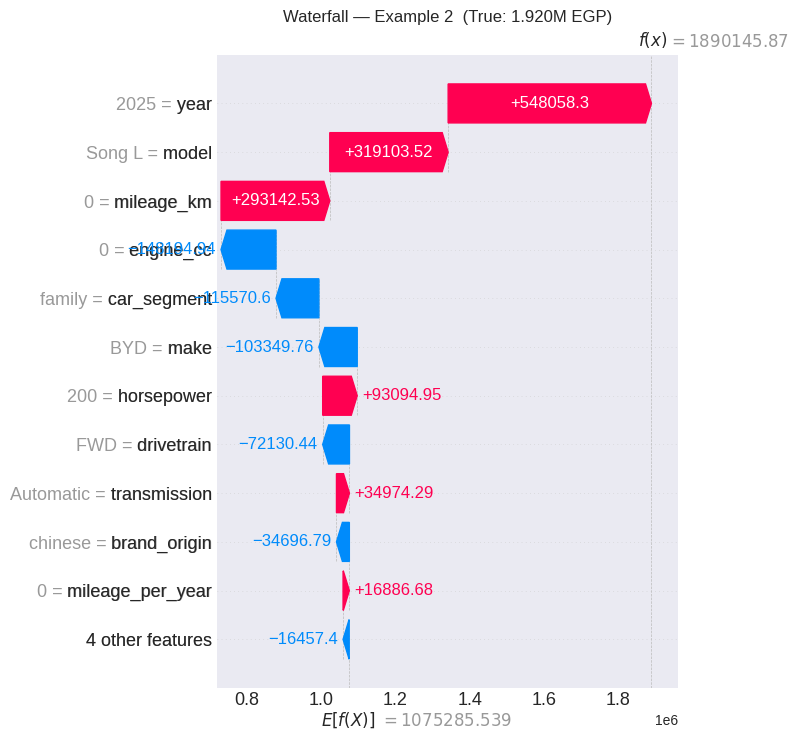

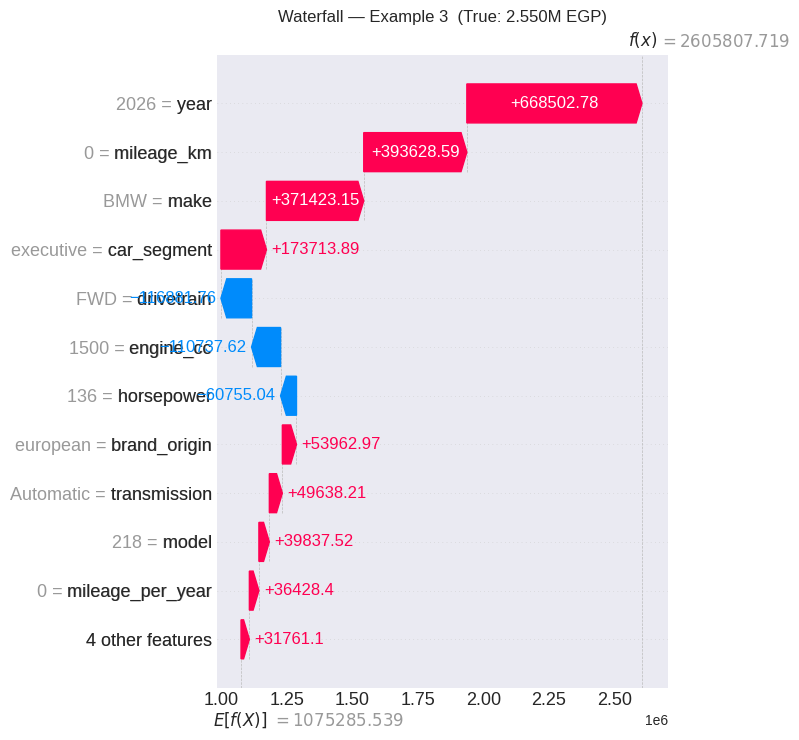

In [54]:
# ── Waterfall plots — 3 example predictions ───────────────────────────────────
lgbm_sv_exp = lgbm_expl(X_shap)

for i, si in enumerate([0, len(X_shap) // 2, len(X_shap) - 1]):
    true_price = df_raw.loc[te_shap, 'price_egp'].iloc[si]
    plt.figure(figsize=(10, 4))
    shap.plots.waterfall(lgbm_sv_exp[si], show=False, max_display=12)
    plt.title(f'Waterfall — Example {i+1}  (True: {true_price/1e6:.3f}M EGP)')
    plt.tight_layout()
    plt.savefig(PLOT_DIR / f'shap_waterfall_{i}.png', dpi=120, bbox_inches='tight')
    plt.show()

Computing SHAP values (XGBoost median) ...


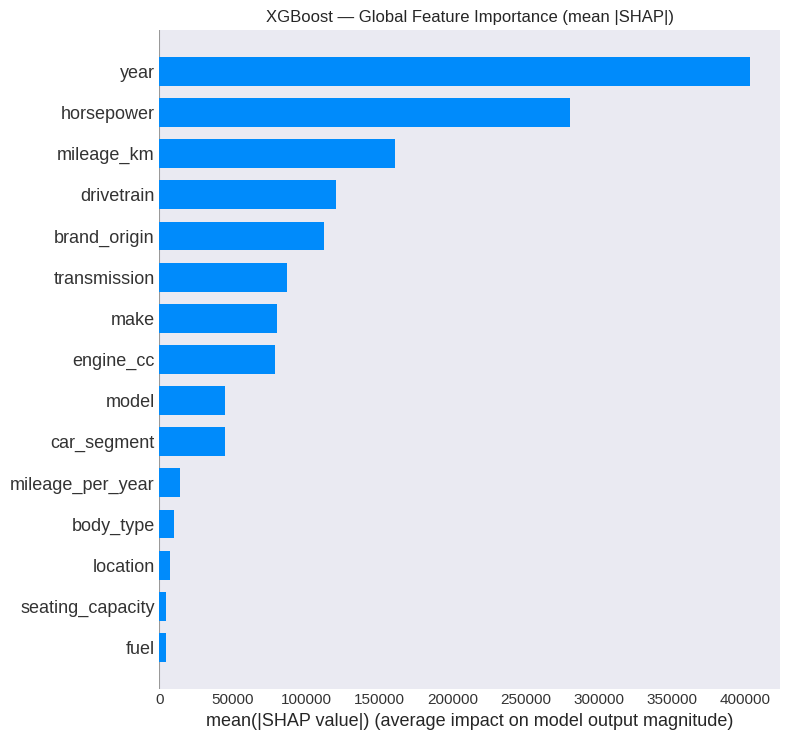

In [55]:
# ── XGBoost SHAP bar ──────────────────────────────────────────────────────────
print('Computing SHAP values (XGBoost median) ...')
xgb_med  = xgb_store['price_egp'][TUNE_SPLIT]['median']
X_shap_x = X_xgb_all.loc[te_shap].copy()
xgb_expl = shap.TreeExplainer(xgb_med)
xgb_sv   = xgb_expl.shap_values(X_shap_x)

plt.figure(figsize=(10, 5))
shap.summary_plot(xgb_sv, X_shap_x, plot_type='bar', show=False, max_display=20)
plt.title('XGBoost — Global Feature Importance (mean |SHAP|)')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'shap_xgb_summary.png', dpi=120, bbox_inches='tight')
plt.show()

## 14) Residual Analysis

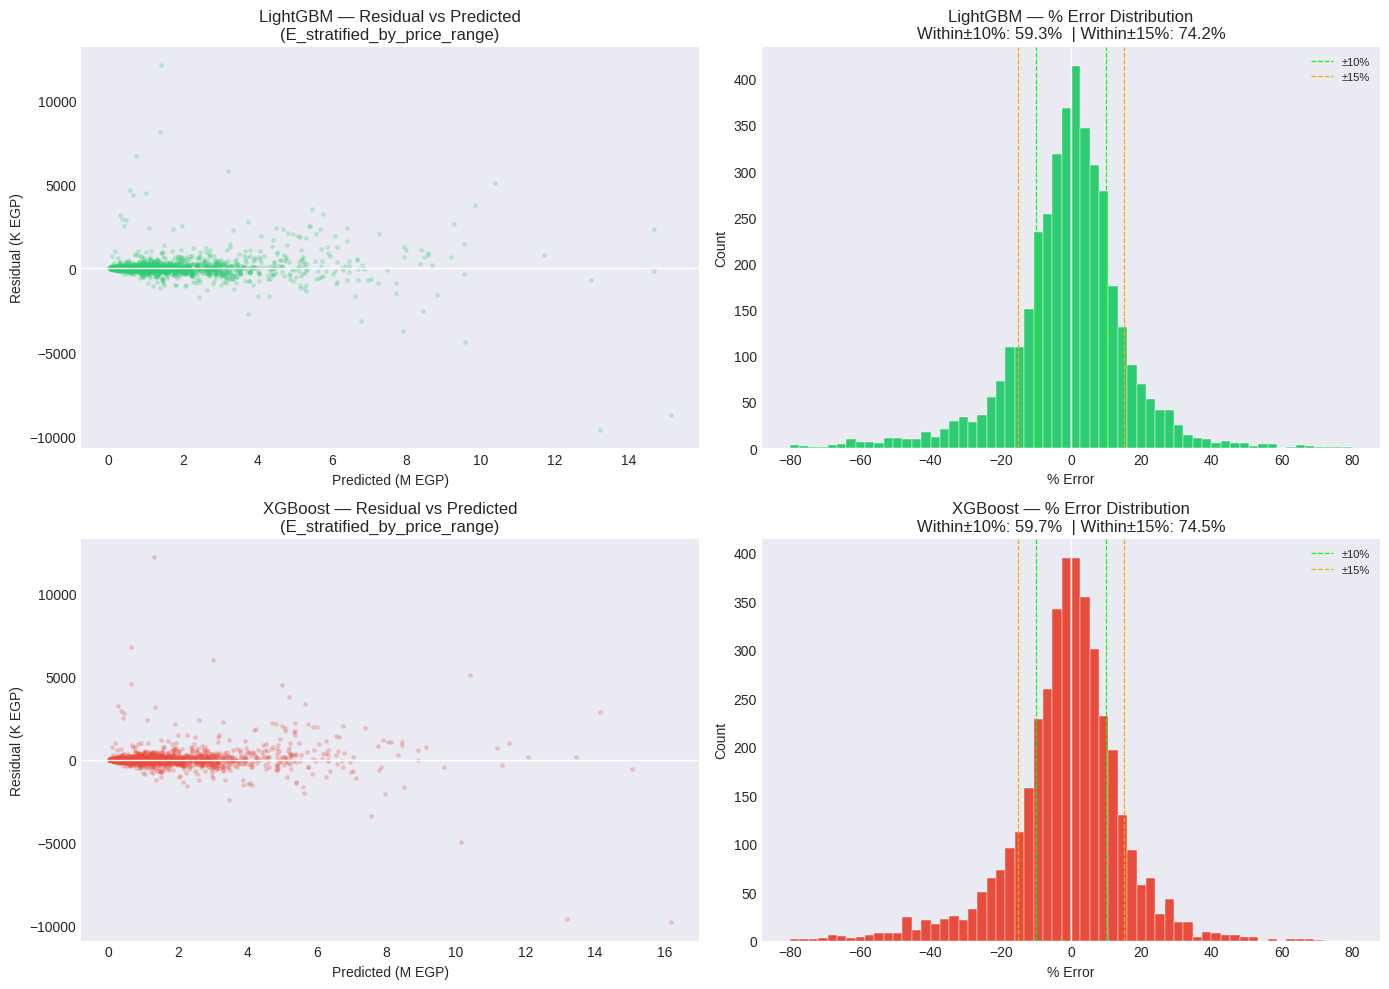

In [56]:
_, te_res = split_indices[TUNE_SPLIT]
y_te_res  = df_raw.loc[te_res, 'price_egp'].to_numpy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for row, fw in enumerate(['LightGBM', 'XGBoost']):
    mods = (lgbm_store if fw == 'LightGBM' else xgb_store)['price_egp'][TUNE_SPLIT]
    if fw == 'LightGBM':
        pred = mods['median'].predict(X_lgbm_all.loc[te_res])
    else:
        dm   = xgb.DMatrix(X_xgb_all.loc[te_res], enable_categorical=True)
        pred = mods['median'].predict(dm)

    resid   = y_te_res - pred
    pct_err = (resid / np.maximum(np.abs(y_te_res), 1e-9)) * 100

    ax0 = axes[row][0]
    ax0.scatter(pred / 1e6, resid / 1e3, alpha=0.2, s=6, color=FW_COLORS[fw])
    ax0.axhline(0, color='white', lw=1)
    ax0.set_xlabel('Predicted (M EGP)'); ax0.set_ylabel('Residual (K EGP)')
    ax0.set_title(f'{fw} — Residual vs Predicted\n({TUNE_SPLIT})')

    ax1 = axes[row][1]
    ax1.hist(pct_err, bins=60, color=FW_COLORS[fw], edgecolor='white', lw=0.3, range=(-80, 80))
    ax1.axvline(0,   color='white',  lw=1)
    ax1.axvline(-10, color='lime',   ls='--', lw=0.9, label='±10%')
    ax1.axvline(10,  color='lime',   ls='--', lw=0.9)
    ax1.axvline(-15, color='orange', ls='--', lw=0.9, label='±15%')
    ax1.axvline(15,  color='orange', ls='--', lw=0.9)
    w10 = float(np.mean(np.abs(pct_err) <= 10) * 100)
    w15 = float(np.mean(np.abs(pct_err) <= 15) * 100)
    ax1.set_xlabel('% Error'); ax1.set_ylabel('Count')
    ax1.set_title(f'{fw} — % Error Distribution\nWithin±10%: {w10:.1f}%  | Within±15%: {w15:.1f}%')
    ax1.legend(fontsize=8)

plt.tight_layout()
plt.savefig(PLOT_DIR / 'residual_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

## 15) LightGBM vs XGBoost — Verdict & Radar Chart

In [57]:
# ── Build comparison row per framework (using best target = price_egp, TUNE_SPLIT) ─
comp_rows = []

for fw in ['LightGBM', 'XGBoost']:
    # point estimate
    row_pt = results_by_target['price_egp']
    row_pt = row_pt[(row_pt['framework'] == fw) & (row_pt['split'] == TUNE_SPLIT)].iloc[0]

    # CI
    row_ci = ci_results[
        (ci_results['train_target'] == 'price_egp') &
        (ci_results['framework']    == fw) &
        (ci_results['split']        == TUNE_SPLIT)
    ].iloc[0]

    # CV
    cv_mape = np.mean([m['MAPE_pct'] for m in cv_results[fw]])
    cv_r2   = np.mean([m['R2']       for m in cv_results[fw]])
    cv_mape_std = np.std([m['MAPE_pct'] for m in cv_results[fw]])

    comp_rows.append(dict(
        Framework        = fw,
        R2               = float(row_pt['R2']),
        MAPE_pct         = float(row_pt['MAPE_pct']),
        MAE_EGP          = float(row_pt['MAE']),
        Within_10pct     = float(row_pt['Within_10pct']),
        Within_15pct     = float(row_pt['Within_15pct']),
        CV_MAPE_pct      = cv_mape,
        CV_MAPE_std      = cv_mape_std,
        CV_R2            = cv_r2,
        Coverage_80_pct  = float(row_ci['Coverage_pct']),
        Mono_violations  = int(row_ci['Mono_violations']),
        Mean_width_pct   = float(row_ci['Mean_width_pct']),
    ))

comp = pd.DataFrame(comp_rows).set_index('Framework')
print('\n=== LightGBM vs XGBoost Comparison (split:', TUNE_SPLIT, ')===')
display(comp.T)

print('\n--- Targets (doc §03-MODEL-STRATEGY) ---')
print(f'{"Metric":<25} {"GOOD":>10} {"EXCELLENT":>12}')
for m, g, e in [("R2","≥ 0.85","≥ 0.90"),("MAPE%","≤ 15%","≤ 12%"),
                ("Within±15%","≥ 75%","≥ 85%"),("CI Coverage","≥ 75%","≥ 78%")]:
    print(f'{m:<25} {g:>10} {e:>12}')


=== LightGBM vs XGBoost Comparison (split: E_stratified_by_price_range )===


Framework,LightGBM,XGBoost
R2,0.879,0.893
MAPE_pct,13.617,13.534
MAE_EGP,"147,359.366","138,277.465"
Within_10pct,59.288,59.659
Within_15pct,74.153,74.499
CV_MAPE_pct,14.898,14.540
CV_MAPE_std,0.876,0.956
CV_R2,0.866,0.886
Coverage_80_pct,78.382,87.707
Mono_violations,0.000,0.000



--- Targets (doc §03-MODEL-STRATEGY) ---
Metric                          GOOD    EXCELLENT
R2                            ≥ 0.85       ≥ 0.90
MAPE%                          ≤ 15%        ≤ 12%
Within±15%                     ≥ 75%        ≥ 85%
CI Coverage                    ≥ 75%        ≥ 78%


In [58]:
# ── Target-check table ────────────────────────────────────────────────────────
checks = [
    ('R2',           'R2',           '>',  0.85),
    ('MAPE%',        'MAPE_pct',     '<',  15.0),
    ('Within±15%',   'Within_15pct', '>',  75.0),
    ('CI Coverage',  'Coverage_80_pct','>',75.0),
    ('CI Width%',    'Mean_width_pct','<', 30.0),
    ('CV MAPE%',     'CV_MAPE_pct',  '<',  15.0),
]
print(f'{"Metric":<20} {"Threshold":<12} {"LightGBM":>12} {"XGBoost":>12}')
print('-' * 58)
for label, col, direction, thr in checks:
    row_lgbm = float(comp.loc['LightGBM', col])
    row_xgb  = float(comp.loc['XGBoost',  col])
    ok_l = (row_lgbm > thr) if direction == '>' else (row_lgbm < thr)
    ok_x = (row_xgb  > thr) if direction == '>' else (row_xgb  < thr)
    sym = {'True': '✓', 'False': '✗'}
    print(f'{label:<20} {direction}{thr:<10} {row_lgbm:>8.2f} {sym[str(ok_l)]:>3}   {row_xgb:>8.2f} {sym[str(ok_x)]:>3}')

Metric               Threshold        LightGBM      XGBoost
----------------------------------------------------------
R2                   >0.85           0.88   ✓       0.89   ✓
MAPE%                <15.0          13.62   ✓      13.53   ✓
Within±15%           >75.0          74.15   ✗      74.50   ✗
CI Coverage          >75.0          78.38   ✓      87.71   ✓
CI Width%            <30.0          61.71   ✗      86.45   ✗
CV MAPE%             <15.0          14.90   ✓      14.54   ✓


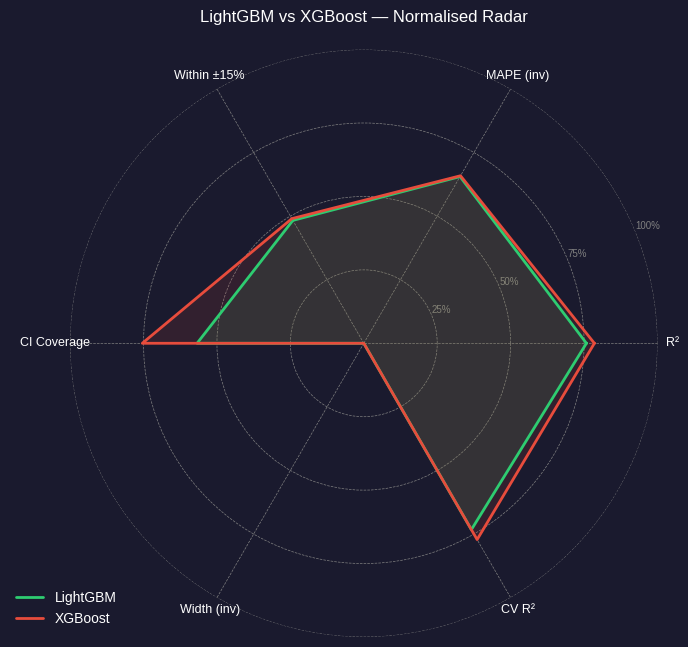

In [59]:
# ── Radar chart ───────────────────────────────────────────────────────────────
radar_cfg = {
    'R²'           : dict(col='R2',             better='high', worst=0.5, best=1.0),
    'MAPE (inv)'   : dict(col='MAPE_pct',       better='low',  worst=30,  best=5),
    'Within ±15%'  : dict(col='Within_15pct',   better='high', worst=50,  best=100),
    'CI Coverage'  : dict(col='Coverage_80_pct',better='high', worst=50,  best=100),
    'Width (inv)'  : dict(col='Mean_width_pct', better='low',  worst=50,  best=10),
    'CV R²'        : dict(col='CV_R2',          better='high', worst=0.5, best=1.0),
}

def norm(val, cfg):
    if cfg['better'] == 'high':
        return np.clip((val - cfg['worst']) / (cfg['best'] - cfg['worst']), 0, 1)
    return np.clip((cfg['worst'] - val) / (cfg['worst'] - cfg['best']), 0, 1)

cats = list(radar_cfg.keys())
N    = len(cats)
ang  = [n / N * 2 * np.pi for n in range(N)] + [0]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.set_facecolor('#1a1a2e'); fig.patch.set_facecolor('#1a1a2e')

for fw in ['LightGBM', 'XGBoost']:
    vals = [norm(float(comp.loc[fw, cfg['col']]), cfg) for cfg in radar_cfg.values()] + [0]
    vals[-1] = vals[0]    # close polygon
    ax.plot(ang, vals, lw=2, color=FW_COLORS[fw], label=fw)
    ax.fill(ang, vals, alpha=0.12, color=FW_COLORS[fw])

ax.set_xticks(ang[:-1]); ax.set_xticklabels(cats, size=9, color='white')
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['25%', '50%', '75%', '100%'], size=7, color='gray')
ax.spines['polar'].set_color('gray')
ax.grid(color='gray', ls='--', lw=0.5)
ax.set_title('LightGBM vs XGBoost — Normalised Radar', color='white', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1), facecolor='#1a1a2e',
          labelcolor='white', framealpha=0.7)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'radar_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

In [60]:
# ── Verdict ───────────────────────────────────────────────────────────────────
lgbm_mape = float(comp.loc['LightGBM', 'MAPE_pct'])
xgb_mape  = float(comp.loc['XGBoost',  'MAPE_pct'])
winner     = 'LightGBM' if lgbm_mape <= xgb_mape else 'XGBoost'

print('\n' + '='*70)
print('  MODEL SELECTION VERDICT')
print('='*70)
print(f'  LightGBM MAPE : {lgbm_mape:.2f}%   (CV: {float(comp.loc["LightGBM","CV_MAPE_pct"]):.2f}% ± {float(comp.loc["LightGBM","CV_MAPE_std"]):.2f}%)')
print(f'  XGBoost  MAPE : {xgb_mape:.2f}%   (CV: {float(comp.loc["XGBoost","CV_MAPE_pct"]):.2f}% ± {float(comp.loc["XGBoost","CV_MAPE_std"]):.2f}%)')
print(f'  → Selected model : {winner}')
print('='*70)


  MODEL SELECTION VERDICT
  LightGBM MAPE : 13.62%   (CV: 14.90% ± 0.88%)
  XGBoost  MAPE : 13.53%   (CV: 14.54% ± 0.96%)
  → Selected model : XGBoost


## 16) Export Best Model Artifacts

Saves to `models/v1.0.0/`  Model Artifacts**.

In [61]:
EXPORT_FW    = winner          # auto-selected; override here if needed: 'LightGBM' or 'XGBoost'
EXPORT_SPLIT = TUNE_SPLIT

print(f'Exporting {EXPORT_FW} quantile models → {OUT_DIR}')

if EXPORT_FW == 'LightGBM':
    mods_exp = lgbm_store['price_egp'][EXPORT_SPLIT]
    for q_name, m in mods_exp.items():
        p = OUT_DIR / f'model_{q_name}_lgbm.txt'
        m.save_model(str(p))
        print('  Saved:', p)
    joblib.dump(mods_exp, OUT_DIR / 'lgbm_quantile_models.joblib')
    print('  Saved: lgbm_quantile_models.joblib')
else:
    mods_exp = xgb_store['price_egp'][EXPORT_SPLIT]
    for q_name, m in mods_exp.items():
        p = OUT_DIR / f'model_{q_name}_xgb.ubj'
        m.save_model(str(p))
        print('  Saved:', p)
    joblib.dump(mods_exp, OUT_DIR / 'xgb_quantile_models.joblib')
    print('  Saved: xgb_quantile_models.joblib')

# Always save label encoders (needed for XGBoost at inference time)
joblib.dump(label_encoders, OUT_DIR / 'label_encoders.joblib')
print('  Saved: label_encoders.joblib')

Exporting XGBoost quantile models → /home/mo-seif/Documents/GP/ml-service/models/pickles
  Saved: /home/mo-seif/Documents/GP/ml-service/models/pickles/model_lower_xgb.ubj
  Saved: /home/mo-seif/Documents/GP/ml-service/models/pickles/model_median_xgb.ubj
  Saved: /home/mo-seif/Documents/GP/ml-service/models/pickles/model_upper_xgb.ubj
  Saved: xgb_quantile_models.joblib
  Saved: label_encoders.joblib


In [ ]:
# ── metadata.json ─────────────────────────────────────────────────────────────
from app.core.model_registry import save_model_metadata, register_model

model_id = f"{EXPORT_FW.lower()}_quantile_{MODEL_VERSION}"

metadata = {
    'version'            : MODEL_VERSION,
    'framework'          : EXPORT_FW,
    'model_id'           : model_id,
    'export_split'       : EXPORT_SPLIT,
    'training_date'      : datetime.datetime.utcnow().isoformat() + 'Z',
    'target_col'         : 'price_egp',
    'is_log_target'      : False,
    'n_train'            : int(len(split_indices[EXPORT_SPLIT][0])),
    'n_test'             : int(len(split_indices[EXPORT_SPLIT][1])),
    'n_features'         : len(FEATURE_COLS),
    'feature_cols'       : FEATURE_COLS,
    'cat_cols'           : CAT_COLS,
    'num_cols'           : NUM_COLS,
    'quantiles'          : QUANTILES,
    'optuna_trials'      : N_TRIALS,
    'lgbm_best_params'   : LGBM_BEST,
    'xgb_best_params'    : XGB_BEST,
    'selected_model'     : winner,
    'test_metrics_lgbm'  : {k: float(v) for k, v in comp.loc['LightGBM'].items()},
    'test_metrics_xgb'   : {k: float(v) for k, v in comp.loc['XGBoost'].items()},
    'cv_lgbm_mape_mean'  : float(np.mean([m['MAPE_pct'] for m in cv_results['LightGBM']])),
    'cv_lgbm_mape_std'   : float(np.std([m['MAPE_pct']  for m in cv_results['LightGBM']])),
    'cv_xgb_mape_mean'   : float(np.mean([m['MAPE_pct'] for m in cv_results['XGBoost']])),
    'cv_xgb_mape_std'    : float(np.std([m['MAPE_pct']  for m in cv_results['XGBoost']])),
    'plot_dir'           : str(PLOT_DIR),
    'source_notebook'    : '05_xgboost_lgbm_quantile',
}

meta_path = save_model_metadata(metadata, filename=f"{model_id}.json")
print('Saved metadata →', meta_path)

Saved metadata → /home/mo-seif/Documents/GP/ml-service/models/metadata/XGBoost_quantile_v1.0.0.json


In [ ]:
# ── Update model registry ─────────────────────────────────────────────────────
from app.core.model_registry import register_model, promote_active_model

model_id = f"{EXPORT_FW.lower()}_quantile_{MODEL_VERSION}"
pkl_name = 'lgbm_quantile_models.joblib' if EXPORT_FW == 'LightGBM' else 'xgb_quantile_models.joblib'

# Build rich metrics dict from the comparison table
_fw_metrics = comp.loc[EXPORT_FW]
register_metrics = {
    'MAPE_pct':       float(_fw_metrics.get('MAPE_pct', 0)),
    'MAE':            float(_fw_metrics.get('MAE', 0)),
    'RMSE':           float(_fw_metrics.get('RMSE', 0)),
    'R2':             float(_fw_metrics.get('R2', 0)),
    'Within_10pct':   float(_fw_metrics.get('Within_10pct', 0)),
    'Within_15pct':   float(_fw_metrics.get('Within_15pct', 0)),
}
# Add interval metrics if present
for col in ('Coverage_80_pct', 'Mean_width_pct'):
    if col in _fw_metrics.index:
        register_metrics[col] = float(_fw_metrics[col])

register_model(
    model_id,
    pkl_path=str(OUT_DIR / pkl_name),
    meta_path=str(meta_path),
    framework=EXPORT_FW,
    version=MODEL_VERSION,
    metrics=register_metrics,
    source_notebook='notebooks/05_xgboost_lgbm_quantile.ipynb',
    artifacts={
        'diagnostics_csv': str(ML_ROOT / 'models' / 'metadata' / 'make_model_mape.csv'),
    },
)
promote_active_model(model_id)

print(f'Registered and promoted model: {model_id}')
print(f'  → Active model in model_registry.json')

Registered and promoted model: XGBoost_quantile_v1.0.0
  → Active model in model_registry.json


## 17) Final Summary

In [64]:
print('\n' + '='*75)
print('  NOTEBOOK 05 — FINAL SUMMARY')
print('='*75)
print(f'  Dataset         : {len(df_raw):,} rows, {len(FEATURE_COLS)} features ({len(NUM_COLS)} numeric + {len(CAT_COLS)} categorical)')
print(f'  Targets tested  : {TARGETS_TO_BENCH}')
print(f'  Splits tested   : {list(split_indices.keys())}')
print(f'  Optuna trials   : {N_TRIALS} per framework')
print(f'  Quantiles       : {QUANTILES}')
print(f'  Tuning split    : {TUNE_SPLIT}')
print()
print(f'  === Key Metrics on {TUNE_SPLIT} (target=price_egp) ===')
hdr = f'  {"Metric":<20} {"LightGBM":>12} {"XGBoost":>12}'
print(hdr); print('  ' + '-'*(len(hdr)-2))
for col in ['R2', 'MAPE_pct', 'Within_15pct', 'CV_MAPE_pct', 'Coverage_80_pct', 'Mean_width_pct']:
    print(f'  {col:<20} {float(comp.loc["LightGBM", col]):>12.3f} {float(comp.loc["XGBoost", col]):>12.3f}')
print()
print(f'  → SELECTED MODEL : {winner}')
print(f'  → Artifacts saved: {OUT_DIR}')
print('='*75)


  NOTEBOOK 05 — FINAL SUMMARY
  Dataset         : 20,214 rows, 15 features (6 numeric + 9 categorical)
  Targets tested  : ['price_egp', 'price_egp_log']
  Splits tested   : ['A_random_rows', 'B_within_make_model_rows', 'C_split_by_make_only', 'D_stratified_by_make', 'E_stratified_by_price_range']
  Optuna trials   : 100 per framework
  Quantiles       : {'lower': 0.05, 'median': 0.5, 'upper': 0.95}
  Tuning split    : E_stratified_by_price_range

  === Key Metrics on E_stratified_by_price_range (target=price_egp) ===
  Metric                   LightGBM      XGBoost
  ----------------------------------------------
  R2                          0.879        0.893
  MAPE_pct                   13.617       13.534
  Within_15pct               74.153       74.499
  CV_MAPE_pct                14.898       14.540
  Coverage_80_pct            78.382       87.707
  Mean_width_pct             61.713       86.452

  → SELECTED MODEL : XGBoost
  → Artifacts saved: /home/mo-seif/Documents/GP/ml-se